In [11]:
import pandas as pd
from pathlib import Path
import numpy as np

In [12]:
import os
full_numerics_dir = '/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/full_trajectories'

numerics_files = os.listdir(full_numerics_dir)
len(numerics_files)

8172

In [13]:
import pandas as pd

records = pd.read_csv(
    "/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/useful_csv/RECORDS-numerics.txt",
    sep="\t", header=None
)

# Split the path into columns
split_cols = records[0].str.split("/", expand=True)
split_cols.columns = ["dir1", "dir2", "filename"]

# Clean dir2: strip leading "p", then cast to int to drop leading zeros
split_cols["dir2_clean"] = split_cols["dir2"].str.lstrip("p").astype(int)

print(split_cols.head())

  dir1     dir2                   filename  dir2_clean
0  p00  p000020  p000020-2183-04-28-17-47n          20
1  p00  p000030  p000030-2172-10-16-12-22n          30
2  p00  p000033  p000033-2116-12-24-12-35n          33
3  p00  p000033  p000033-2116-12-25-13-11n          33
4  p00  p000052  p000052-2191-01-10-02-21n          52


In [14]:
split_cols

,dir1,dir2,filename,dir2_clean
0,p00,p000020,p000020-2183-04-28-17-47n,20
1,p00,p000030,p000030-2172-10-16-12-22n,30
2,p00,p000033,p000033-2116-12-24-12-35n,33
3,p00,p000033,p000033-2116-12-25-13-11n,33
4,p00,p000052,p000052-2191-01-10-02-21n,52
...,...,...,...,...
22242,p09,p099982,p099982-2157-01-06-16-31n,99982
22243,p09,p099982,p099982-2157-02-16-17-37n,99982
22244,p09,p099983,p099983-2193-04-26-12-01n,99983
22245,p09,p099992,p099992-2144-07-25-20-39n,99992


In [15]:
icu_stays = pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/input_data/ICUSTAYS.csv')

In [16]:
icu_stays['HADM_ID'].nunique()

57786

In [17]:
subject_ids_with_waveforms = set(icu_stays['SUBJECT_ID'].unique()) & set(split_cols['dir2_clean'])

In [18]:
len(subject_ids_with_waveforms)

10260

In [19]:
icu_stays_w_waveforms = icu_stays[icu_stays['SUBJECT_ID'].isin(subject_ids_with_waveforms)]

In [20]:
icu_stays_w_waveforms['HADM_ID'].nunique()

15822

In [21]:
icu_stays_w_waveforms['HADM_ID'].nunique() / icu_stays['HADM_ID'].nunique() *100

27.380334337036654

In [22]:
icu_stays_w_waveforms['SUBJECT_ID'].nunique()

10260

In [23]:
items_df = pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/input_data/D_ITEMS.csv')

items_df.head()

,ROW_ID,ITEMID,LABEL,ABBREVIATION,DBSOURCE,LINKSTO,CATEGORY,UNITNAME,PARAM_TYPE,CONCEPTID
0,457,497,Patient controlled analgesia (PCA) [Inject],NaN,carevue,chartevents,NaN,NaN,NaN,NaN
1,458,498,PCA Lockout (Min),NaN,carevue,chartevents,NaN,NaN,NaN,NaN
2,459,499,PCA Medication,NaN,carevue,chartevents,NaN,NaN,NaN,NaN
3,460,500,PCA Total Dose,NaN,carevue,chartevents,NaN,NaN,NaN,NaN
4,461,501,PCV Exh Vt (Obser),NaN,carevue,chartevents,NaN,NaN,NaN,NaN


In [24]:
INPUT_DATA_DIR = Path('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/input_data')

hadm_ids = icu_stays_w_waveforms['HADM_ID'].unique()


In [25]:
def attach_item_labels(inputs_df: pd.DataFrame, items_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds a string label for each item_id using D_ITEMS.
    Creates a new column 'item_label'. If no match, falls back to str(item_id).
    """
    # tolerate case differences (MIMIC-III/IV)
    items = items_df.rename(columns=str.lower)
    if not {"itemid", "label"}.issubset(items.columns):
        raise ValueError("items_df must have columns ITEMID and LABEL (any case).")

    items_slim = items[["itemid", "label"]].drop_duplicates()

    df = inputs_df.merge(items_slim, left_on="item_id", right_on="itemid", how="left")
    df = df.drop(columns=["itemid"])
    df["item_label"] = df["label"].fillna(df["item_id"].astype(str))
    df = df.drop(columns=["label"])  # keep things tidy (label now lives in item_label)
    return df

In [26]:
import pandas as pd
import numpy as np
from typing import Optional


def build_inputs_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean IV/medication input events and return a tidy dataframe with:
       subject_id, hadm_id, item_id, input_name, input_class,
       start_time, end_time, rate, rate_uom,
       patientweight,
       rate/weight,           # weight-normalized rate
       rate/weight_capped,    # per-item_id cap at 95th percentile
       rate/weight_norm       # per-item_id 0–1 normalization (divide by 95th pct)

    Rules:
    - Remove cancelled/rejected rows.
    - If rate_uom already encodes per-kg (e.g., 'mcg/kg/min', 'per kg'), then 'rate/weight' == 'rate'.
    - Otherwise, 'rate/weight' = rate / patientweight.
    - patientweight values of 1 or NaN are replaced with the cohort mean of valid weights.
    - For each item_id, cap 'rate/weight' at the 95th percentile.
    - Normalize per item_id by dividing by the 95th percentile.
    - Sorted by hadm_id, item_id, start_time.
    """
    if df.empty:
        return pd.DataFrame()

    # ---- Column resolver
    lower = {c.lower(): c for c in df.columns}

    def pick(*cands: str) -> Optional[str]:
        for c in cands:
            if c.lower() in lower:
                return lower[c.lower()]
        return None

    col_subject = pick("subject_id", "subjectid")
    col_hadm = pick("hadm_id", "hadmid")
    col_item = pick("item_id", "itemid")
    col_name = pick("ordercategoryname")
    col_class = pick("ordercategorydescription")
    col_start = pick("start_time", "starttime", "startdate", "charttime")
    col_end = pick("end_time", "endtime", "enddate", "stoptime")
    col_rate = pick("rate")
    col_rate_u = pick("rate_uom", "rateuom")
    col_weight = pick("patientweight", "weight", "actualbedweight")

    needed = [col_subject, col_hadm, col_item, col_start, col_end, col_rate]
    if any(c is None for c in needed):
        raise ValueError(f"Missing required columns; found: {needed}")

    # ---- Remove cancelled/rejected
    cancel_cols = [
        c
        for c in [
            pick("cancelreason"),
            pick("iscanceled"),
            pick("is_canceled"),
            pick("iscancelled"),
            pick("is_cancelled"),
            pick("canceled"),
            pick("cancelled"),
        ]
        if c is not None
    ]
    status_col = pick("statusdescription", "status", "orderstatus")
    comments_cancel_col = pick("comments_cancelledby", "comments_canceledby")

    keep = pd.Series(True, index=df.index)
    for c in cancel_cols:
        s = df[c]
        keep &= (
            s.isna()
            | (s == 0)
            | (s is False)
            | (s.astype(str).str.strip().isin(["0", "False", "false"]))
        )
    if status_col is not None:
        keep &= ~df[status_col].astype(str).str.contains(
            r"cancel|reject|discontinu", case=False, na=False
        )
    if comments_cancel_col is not None:
        keep &= df[comments_cancel_col].isna()

    dfc = df.loc[keep].copy()

    # ---- Select & normalize
    out_cols = [
        col_subject,
        col_hadm,
        col_item,
        col_name,
        col_class,
        col_start,
        col_end,
        col_rate,
    ]
    if col_rate_u is not None:
        out_cols.append(col_rate_u)
    if col_weight is not None:
        out_cols.append(col_weight)

    out = dfc[out_cols].copy()

    # Convert datetimes
    out[col_start] = pd.to_datetime(out[col_start], errors="coerce", utc=True)
    out[col_end] = pd.to_datetime(out[col_end], errors="coerce", utc=True)

    # Numeric conversions
    out[col_rate] = pd.to_numeric(out[col_rate], errors="coerce")
    if col_weight is not None:
        out[col_weight] = pd.to_numeric(out[col_weight], errors="coerce")

    # ---- Rename to desired schema (normalize names)
    rename_map = {
        col_subject: "subject_id",
        col_hadm: "hadm_id",
        col_item: "item_id",
        col_name: "input_name",
        col_class: "input_class",
        col_start: "start_time",
        col_end: "end_time",
        col_rate: "rate",
    }
    if col_rate_u is not None:
        rename_map[col_rate_u] = "rate_uom"
    if col_weight is not None:
        rename_map[col_weight] = "patientweight"

    out = out.rename(columns=rename_map)

    # Ensure expected columns exist
    for must_col in ["input_name", "input_class", "rate_uom", "patientweight"]:
        if must_col not in out.columns:
            out[must_col] = pd.NA

    # ---- Clean patientweight: replace 1 or NaN with mean of valid weights
    pw = pd.to_numeric(out["patientweight"], errors="coerce")
    valid = pw[(~pw.isna()) & (pw != 1)]
    if not valid.empty:
        mean_wt = valid.mean()
        pw = pw.mask((pw.isna()) | (pw == 1), mean_wt)
    out["patientweight"] = pw

    # ---- Compute rate/weight with per-kg guard
    ru = out["rate_uom"].astype(str)
    is_perkg = ru.str.contains(r"/\s*kg\b", case=False, na=False) | ru.str.contains(
        r"\bper\s*kg\b", case=False, na=False
    )

    rw = pd.Series(np.nan, index=out.index, dtype="float64")
    rw.loc[is_perkg] = out.loc[is_perkg, "rate"]
    denom = out["patientweight"].replace({0: np.nan})
    rw.loc[~is_perkg] = out.loc[~is_perkg, "rate"] / denom.loc[~is_perkg]
    out["rate/weight"] = rw

    # ---- Per-item_id capping at 95th percentile
    p95 = out.groupby("item_id")["rate/weight"].transform(
        lambda x: x.quantile(0.95)
    )
    out["rate/weight_capped"] = out["rate/weight"].clip(upper=p95)

    # ---- Per-item_id normalization by 95th percentile
    safe_p95 = p95.where((p95 > 0) & (~p95.isna()))
    norm = out["rate/weight_capped"] / safe_p95
    out["rate/weight_norm"] = norm.clip(lower=0, upper=1)

    if "input_name" in out.columns:
        mask_bolus = out["input_name"].astype(str).str.strip() == "03-IV Fluid Bolus"
        out.loc[mask_bolus, "rate/weight_norm"] = 1.0

    # ---- Sort
    out = out.sort_values(
        ["hadm_id", "item_id", "start_time"], kind="mergesort", na_position="last"
    )

    return out[
        [
            "subject_id",
            "hadm_id",
            "item_id",
            "input_name",
            "input_class",
            "start_time",
            "end_time",
            "rate",
            "rate_uom",
            "patientweight",
            "rate/weight",
            "rate/weight_capped",
            "rate/weight_norm",
        ]
    ].reset_index(drop=True)

In [27]:



inputevents_mv_df = pd.read_csv(INPUT_DATA_DIR / "INPUTEVENTS_MV.csv")
inputevents_mv_df = build_inputs_df(inputevents_mv_df)
inputevents_mv_df = attach_item_labels(inputevents_mv_df, items_df)
inputevents_mv_df = inputevents_mv_df[inputevents_mv_df["hadm_id"].isin(hadm_ids)]
inputevents_mv_df = inputevents_mv_df.sort_values(
    ["hadm_id", "start_time"], ascending=[True, True]
).set_index("hadm_id", drop=False)
inputevents_mv_df.head()

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,patientweight,rate/weight,rate/weight_capped,rate/weight_norm,item_label
hadm_id,,,,,,,,,,,,,,
100001,58526,100001,223258,01-Drips,Continuous Med,2117-09-11 12:50:00+00:00,2117-09-11 12:55:00+00:00,5.000000,units/hour,99.0,0.050505,0.050505,0.265860,Insulin - Regular
100001,58526,100001,225158,01-Drips,Continuous Med,2117-09-11 12:50:00+00:00,2117-09-11 12:55:00+00:00,5.000000,mL/hour,99.0,0.050505,0.050505,0.027003,NaCl 0.9%
100001,58526,100001,223258,01-Drips,Continuous Med,2117-09-11 12:55:00+00:00,2117-09-11 14:00:00+00:00,6.996487,units/hour,99.0,0.070672,0.070672,0.372017,Insulin - Regular
100001,58526,100001,225158,01-Drips,Continuous Med,2117-09-11 12:55:00+00:00,2117-09-11 14:00:00+00:00,6.996487,mL/hour,99.0,0.070672,0.070672,0.037786,NaCl 0.9%
100001,58526,100001,225159,02-Fluids (Crystalloids),Continuous IV,2117-09-11 13:00:00+00:00,2117-09-11 13:47:00+00:00,75.000000,mL/hour,99.0,0.757576,0.757576,0.169912,NaCl 0.45%


In [28]:
inputevents_mv_df[inputevents_mv_df['input_name']=="03-IV Fluid Bolus"]

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,patientweight,rate/weight,rate/weight_capped,rate/weight_norm,item_label
hadm_id,,,,,,,,,,,,,,
100001,58526,100001,225158,03-IV Fluid Bolus,Bolus,2117-09-11 22:24:00+00:00,2117-09-11 22:25:00+00:00,NaN,NaN,99.0,NaN,NaN,1.0,NaCl 0.9%
100001,58526,100001,225828,03-IV Fluid Bolus,Bolus,2117-09-12 04:49:00+00:00,2117-09-12 04:50:00+00:00,NaN,NaN,99.0,NaN,NaN,1.0,LR
100001,58526,100001,225828,03-IV Fluid Bolus,Bolus,2117-09-12 07:57:00+00:00,2117-09-12 07:58:00+00:00,NaN,NaN,99.0,NaN,NaN,1.0,LR
100001,58526,100001,225158,03-IV Fluid Bolus,Bolus,2117-09-15 01:10:00+00:00,2117-09-15 01:11:00+00:00,NaN,NaN,99.0,NaN,NaN,1.0,NaCl 0.9%
100003,54610,100003,225158,03-IV Fluid Bolus,Bolus,2150-04-17 17:58:00+00:00,2150-04-17 17:59:00+00:00,NaN,NaN,85.3,NaN,NaN,1.0,NaCl 0.9%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199979,41115,199979,225828,03-IV Fluid Bolus,Bolus,2182-02-06 19:07:00+00:00,2182-02-06 19:08:00+00:00,NaN,NaN,98.0,NaN,NaN,1.0,LR
199979,41115,199979,225828,03-IV Fluid Bolus,Bolus,2182-02-06 21:49:00+00:00,2182-02-06 21:50:00+00:00,NaN,NaN,98.0,NaN,NaN,1.0,LR
199979,41115,199979,225828,03-IV Fluid Bolus,Bolus,2182-02-06 22:30:00+00:00,2182-02-06 22:31:00+00:00,NaN,NaN,98.0,NaN,NaN,1.0,LR


In [29]:
all_trigger_meds = pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/useful_csv/all_trigger_meds.csv')


In [30]:
all_trigger_meds

,moa,general_name,item_ids
0,Increase Intravascular Volume (Preload),NaCl 0.9% (Normal Saline),"225158,30018,40850,40865,41490,508822"
1,Increase Intravascular Volume (Preload),Lactated Ringers (LR),"225828,30021,27193"
2,Increase Intravascular Volume (Preload),Albumin 5%,"220864,30008,615"
3,Increase Intravascular Volume (Preload),Albumin 25%,"220862,30009,1278"
4,Increase Intravascular Volume (Preload),Hetastarch (Hespan),"225174,30012"
5,Increase Intravascular Volume (Preload),Dextran 40,"225795,30011"
6,Increase Intravascular Volume (Preload),Packed Red Blood Cells (PRBCs),"225168,30001,30179,30004,30104"
7,Increase Total Peripheral Resistance (Afterload),Phenylephrine (Neosynephrine),"221749,30127,30128,4679,122737"
8,Increase Total Peripheral Resistance (Afterload),Norepinephrine (Levophed),"221906,30047,30120,9413,100132"
9,Increase Total Peripheral Resistance (Afterload),Vasopressin,"222315,30051,39670"


In [31]:
trigger_itemids = (
    all_trigger_meds["item_ids"]
    .str.split(",")                 # split into lists of strings
    .explode()                      # flatten into one long Series
    .str.strip()                    # remove spaces
    .astype(int)                    # convert to ints
    .tolist()                       # back to Python list
)

In [32]:
inputevents_mv_df['item_id'] = inputevents_mv_df['item_id'].astype(int)

In [33]:
inputevents_mv_df_trigger_filtered = inputevents_mv_df[inputevents_mv_df["item_id"].isin(trigger_itemids)]
inputevents_mv_df_trigger_filtered = inputevents_mv_df_trigger_filtered[~inputevents_mv_df_trigger_filtered['input_name'].isin(['08-Antibiotics (IV)', '10-Prophylaxis (IV)'])]


In [34]:
per_item_summary = (
    inputevents_mv_df_trigger_filtered.groupby("item_label")["rate/weight_norm"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])
)
per_item_summary

,count,mean,std,min,25%,50%,75%,95%,99%,max
item_label,,,,,,,,,,
Albumin 25%,4504.0,0.438056,0.218645,0.026662,0.280011,0.365278,0.510680,1.000000,1.000000,1.000000
Albumin 5%,4220.0,0.456963,0.238892,0.026688,0.261205,0.409222,0.584602,1.000000,1.000000,1.000000
Dextran 40,2.0,0.147839,0.000000,0.147839,0.147839,0.147839,0.147839,0.147839,0.147839,0.147839
Dopamine,5163.0,0.366715,0.241711,0.025006,0.200129,0.298089,0.501102,0.998510,1.000000,1.000000
Epinephrine,3160.0,0.274453,0.241401,0.018217,0.104146,0.196947,0.364730,0.837367,1.000000,1.000000
Hetastarch (Hespan) 6%,29.0,0.607410,0.454703,0.028641,0.042909,0.967874,0.983333,1.000000,1.000000,1.000000
Isuprel,17.0,0.459117,0.232918,0.045170,0.406532,0.407775,0.504092,0.903746,0.980749,1.000000
LR,19393.0,0.455313,0.435357,0.000037,0.084615,0.149689,1.000000,1.000000,1.000000,1.000000
Milrinone,2820.0,0.524789,0.221995,0.017673,0.353118,0.529802,0.706431,1.000000,1.000000,1.000000


array([[<Axes: title={'center': 'Albumin 25%'}>,
        <Axes: title={'center': 'Albumin 5%'}>,
        <Axes: title={'center': 'Dextran 40'}>,
        <Axes: title={'center': 'Dopamine'}>],
       [<Axes: title={'center': 'Epinephrine'}>,
        <Axes: title={'center': 'Hetastarch (Hespan) 6%'}>,
        <Axes: title={'center': 'Isuprel'}>,
        <Axes: title={'center': 'LR'}>],
       [<Axes: title={'center': 'Milrinone'}>,
        <Axes: title={'center': 'NaCl 0.9%'}>,
        <Axes: title={'center': 'Norepinephrine'}>,
        <Axes: title={'center': 'Packed Red Blood Cells'}>],
       [<Axes: title={'center': 'Phenylephrine'}>,
        <Axes: title={'center': 'Vasopressin'}>, <Axes: >, <Axes: >]],
      dtype=object)

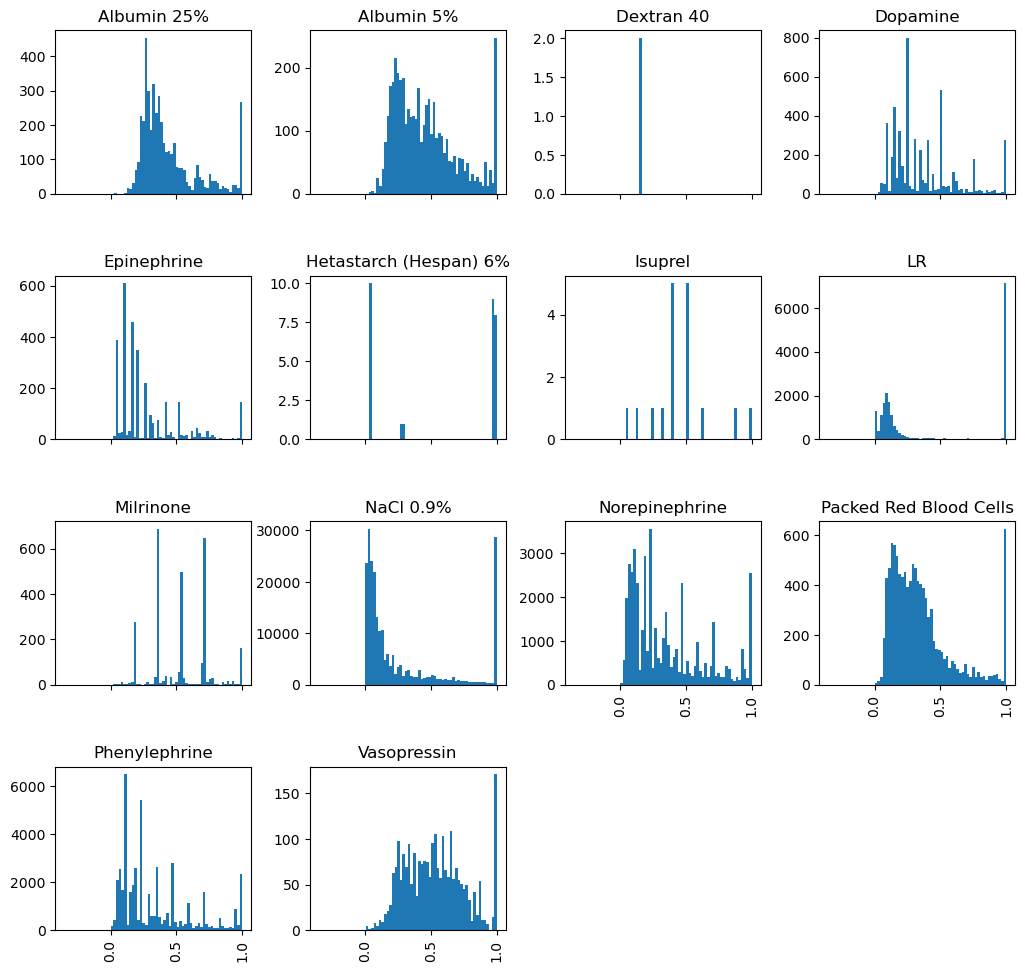

In [35]:
inputevents_mv_df_trigger_filtered.hist(column="rate/weight_norm", by="item_label", bins=50, figsize=(12,12), sharex=True)

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_rate_distributions(df, items=None, bins=50, max_cols=3):
    """
    Plot normalized rate/weight distributions for selected items.
    If items is None, plot for all unique item_labels in the dataframe.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'item_label' and 'rate/weight_norm'
    items : list or None
        List of item_labels to plot. If None, all unique item_labels are used.
    bins : int
        Number of histogram bins.
    max_cols : int
        Max number of subplot columns in grid layout.
    """
    sns.set_style("whitegrid")
    
    # Decide which items to plot
    if items is None:
        items = sorted(df["item_label"].dropna().unique())
    
    n_items = len(items)
    n_cols = min(max_cols, n_items)
    n_rows = (n_items + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3*n_rows), sharex=True)
    axes = axes.flatten() if n_items > 1 else [axes]

    for ax, item in zip(axes, items):
        data = df.loc[df["item_label"] == item, "rate/weight_norm"].dropna()
        sns.histplot(data, bins=bins, kde=False, ax=ax,
                     color="steelblue", edgecolor="white")
        ax.set_title(f"{item}", fontsize=12, weight="bold")
        ax.set_ylabel("Count")
        ax.set_xlim(0, 1)

    # Remove unused subplots if items don't fill the grid
    for ax in axes[n_items:]:
        ax.remove()

    axes[min(n_items, len(axes)) - 1].set_xlabel("Normalized Rate/Weight")
    plt.tight_layout()
    plt.show()

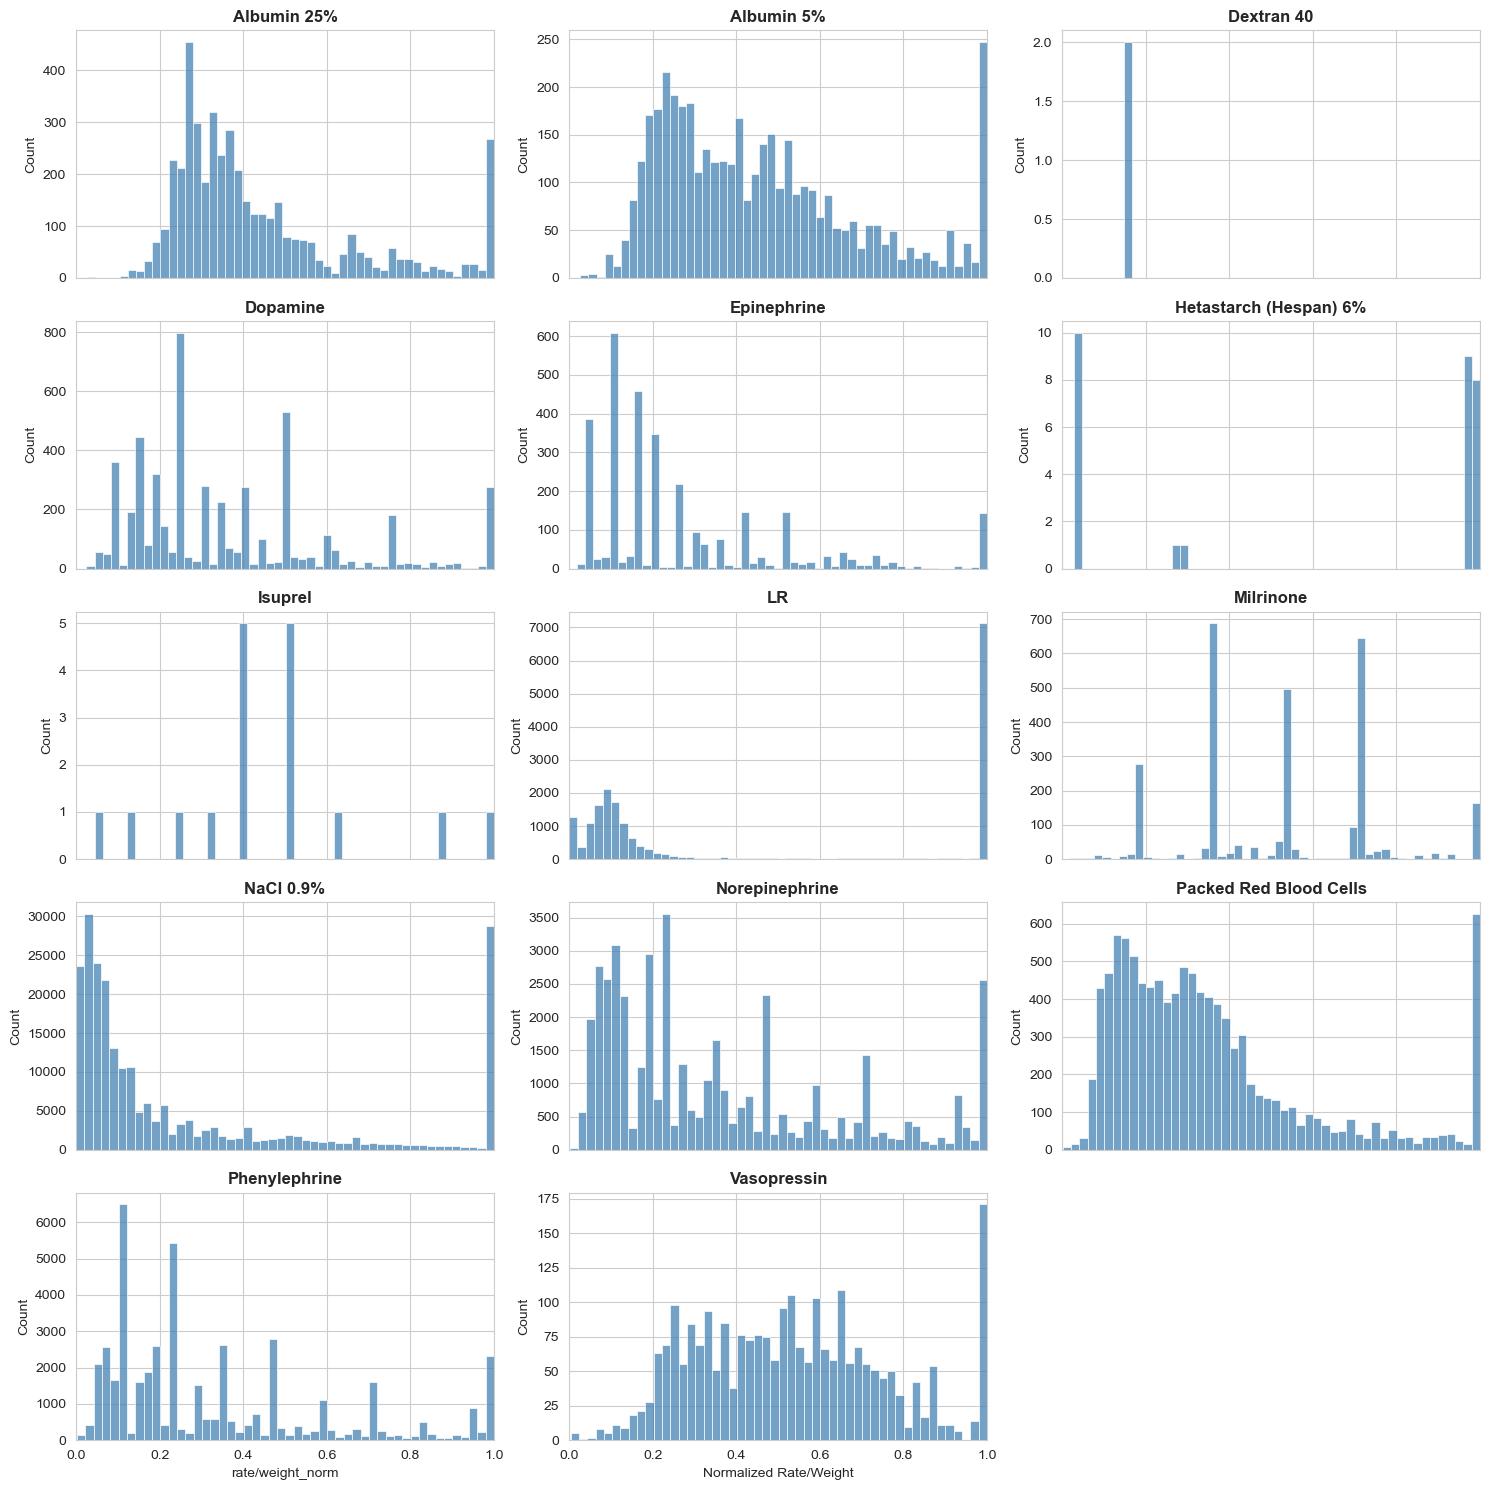

In [37]:
plot_rate_distributions(inputevents_mv_df_trigger_filtered)

In [38]:
original_total_hadm_ids = 57786
inputevents_mv_df_trigger_filtered['hadm_id'].nunique() / original_total_hadm_ids *100

15.80313570761084

In [39]:
inputevents_mv_df_trigger_filtered['input_name'].value_counts()

input_name
01-Drips                    262193
02-Fluids (Crystalloids)     68763
03-IV Fluid Bolus            25410
07-Blood Products            10424
04-Fluids (Colloids)          8755
Name: count, dtype: int64

In [40]:
inputevents_mv_df_trigger_filtered['item_label'].value_counts()

item_label
NaCl 0.9%                 232209
Phenylephrine              46464
Norepinephrine             44611
LR                         19393
Packed Red Blood Cells     10424
Dopamine                    5163
Albumin 25%                 4504
Albumin 5%                  4220
Epinephrine                 3160
Milrinone                   2820
Vasopressin                 2529
Hetastarch (Hespan) 6%        29
Isuprel                       17
Dextran 40                     2
Name: count, dtype: int64

In [41]:
#for i in list(inputevents_mv_df_trigger_filtered['input_name'].unique()):
#    print(i)
#    print(inputevents_mv_df_trigger_filtered[inputevents_mv_df_trigger_filtered['input_name'] == i]['item_label'].value_counts())

In [42]:
nan_by_input = (
    inputevents_mv_df_trigger_filtered
    .groupby("input_name")["rate/weight_norm"]
    .apply(lambda s: s.isna().sum())
)

totals_by_input = inputevents_mv_df_trigger_filtered["input_name"].value_counts()

nan_summary = pd.DataFrame({
    "total": totals_by_input,
    "n_missing": nan_by_input,
})
nan_summary["percent_missing"] = 100 * nan_summary["n_missing"] / nan_summary["total"]
print(nan_summary)

                           total  n_missing  percent_missing
input_name                                                  
01-Drips                  262193          0              0.0
02-Fluids (Crystalloids)   68763          0              0.0
03-IV Fluid Bolus          25410          0              0.0
04-Fluids (Colloids)        8755          0              0.0
07-Blood Products          10424          0              0.0


In [43]:
nan_by_label = (
    inputevents_mv_df_trigger_filtered
    .groupby("item_label")["rate/weight_norm"]
    .apply(lambda s: s.isna().sum())
    .sort_values(ascending=False)
)

print(nan_by_label.head(20))  # top 20 labels with most missing

item_label
Albumin 25%               0
Albumin 5%                0
Dextran 40                0
Dopamine                  0
Epinephrine               0
Hetastarch (Hespan) 6%    0
Isuprel                   0
LR                        0
Milrinone                 0
NaCl 0.9%                 0
Norepinephrine            0
Packed Red Blood Cells    0
Phenylephrine             0
Vasopressin               0
Name: rate/weight_norm, dtype: int64


In [44]:
nan_by_item_id = (
    inputevents_mv_df_trigger_filtered
    .groupby("item_id")["rate/weight_norm"]
    .apply(lambda s: s.isna().sum())
    .sort_values(ascending=False)
)

print(nan_by_item_id)  # top 20 labels with most missing

item_id
220862    0
220864    0
221289    0
221662    0
221749    0
221906    0
221986    0
222315    0
225158    0
225168    0
225174    0
225795    0
225828    0
227692    0
Name: rate/weight_norm, dtype: int64


In [45]:
inputevents_mv_df_trigger_filtered.head()

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,patientweight,rate/weight,rate/weight_capped,rate/weight_norm,item_label
hadm_id,,,,,,,,,,,,,,
100001,58526,100001,225158,01-Drips,Continuous Med,2117-09-11 12:50:00+00:00,2117-09-11 12:55:00+00:00,5.000000,mL/hour,99.0,0.050505,0.050505,0.027003,NaCl 0.9%
100001,58526,100001,225158,01-Drips,Continuous Med,2117-09-11 12:55:00+00:00,2117-09-11 14:00:00+00:00,6.996487,mL/hour,99.0,0.070672,0.070672,0.037786,NaCl 0.9%
100001,58526,100001,225158,02-Fluids (Crystalloids),Continuous IV,2117-09-11 13:48:00+00:00,2117-09-11 15:48:00+00:00,499.999980,mL/hour,99.0,5.050505,1.870324,1.000000,NaCl 0.9%
100001,58526,100001,225158,01-Drips,Continuous Med,2117-09-11 14:00:00+00:00,2117-09-11 16:12:00+00:00,8.990600,mL/hour,99.0,0.090814,0.090814,0.048555,NaCl 0.9%
100001,58526,100001,225158,02-Fluids (Crystalloids),Continuous IV,2117-09-11 15:59:00+00:00,2117-09-11 16:11:00+00:00,199.999998,mL/hour,99.0,2.020202,1.870324,1.000000,NaCl 0.9%


let's define the following triggers + action clusters:


1) any bolus is a trigger 

2) any uptitration of a medication is a trigger (as long as > of 10% of the previous rate/weight)

3) any new medication 

if we have multiple triggers within 20 mins of the first one, they are clustered in an action cluster as we previously said. 



In [46]:
import pandas as pd
import numpy as np

def compute_triggers_simple(
    df: pd.DataFrame,
    uptitration_rel_threshold: float = 0.25,  # ≥25% relative increase
    min_abs_change: float = 0.02,             # ignore micro-jitters smaller than this
) -> pd.DataFrame:
    """
    Triggers (on normalized rate basis):
      1) Bolus: input_name contains 'bolus'
      2) Uptitration: (curr - prev) > 0, (curr - prev)/prev > rel_threshold, and abs(curr - prev) >= min_abs_change
      3) New medication: prev == 0 and curr > 0
         • Special case: if item_label is 'NaCl 0.9%' or 'LR', require curr > 0.5 (normalized) to count as a start
    """
    # --- safe copy / index handling
    df = df.copy()
    if isinstance(df.index, pd.MultiIndex):
        idx_names = [n for n in df.index.names if n is not None]
        if any(n in df.columns for n in idx_names):
            df = df.reset_index(drop=True)
        else:
            df = df.reset_index()
    else:
        idx_name = df.index.name
        if idx_name is not None and idx_name in df.columns:
            df = df.reset_index(drop=True)
        else:
            df = df.reset_index()

    # --- coerce times
    for c in ("start_time", "end_time"):
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

    # --- unified rate (prefer normalized)
    df["rate_norm"] = (
        pd.to_numeric(df.get("rate/weight_norm"), errors="coerce")
        .fillna(pd.to_numeric(df.get("rate/weight"), errors="coerce"))
        .fillna(pd.to_numeric(df.get("rate"), errors="coerce"))
        .fillna(0.0)
    ).clip(0, 1)

    # --- grouping keys
    item_key = "item_label" if "item_label" in df.columns else ("item_id" if "item_id" in df.columns else None)
    group_keys = [k for k in ["subject_id", "hadm_id", item_key] if k and k in df.columns]
    if not group_keys or (item_key is None):
        raise KeyError("Need subject_id, hadm_id, and one of ['item_label','item_id'] to group titrations.")

    # --- order and previous rate
    sort_keys = group_keys + (["start_time"] if "start_time" in df.columns else [])
    df = df.sort_values(sort_keys, kind="mergesort").copy()
    df["prev_rate"] = df.groupby(group_keys, dropna=False)["rate_norm"].shift(1).fillna(0.0)

    # (1) bolus?
    is_bolus = (
        df["input_name"].astype(str).str.contains("bolus", case=False, na=False)
        if "input_name" in df.columns else pd.Series(False, index=df.index)
    )

    # (2) uptitration (relative + absolute guard)
    prev = df["prev_rate"]
    curr = df["rate_norm"]
    delta = curr - prev
    with np.errstate(divide="ignore", invalid="ignore"):
        rel_increase = np.where(prev > 0, delta / prev, np.nan)
    uptitrate = (delta > 0) & (np.nan_to_num(rel_increase, nan=0.0) > uptitration_rel_threshold) & (delta >= min_abs_change)

    # (3) new medication start with saline/LR gate
    first_start_base = (prev == 0) & (curr > 0)
    saline_or_lr = df.get("item_label", pd.Series("", index=df.index)).isin(["NaCl 0.9%", "LR"])
    first_start = first_start_base & ~(saline_or_lr & (curr <= 0.5))

    # Compose trigger + reason
    trigger = is_bolus | uptitrate | first_start
    reason = np.where(
        is_bolus, "bolus",
        np.where(
            uptitrate, f"uptitrate_gt{int(uptitration_rel_threshold*100)}pct_abs>={min_abs_change}",
            np.where(first_start, "start_new_med", "")
        )
    )

    df["trigger"] = trigger
    df["trigger_reason"] = reason
    return df

In [47]:
import pandas as pd
import numpy as np

def _encounter_keys(df: pd.DataFrame):
    keys = []
    if "subject_id" in df.columns: keys.append("subject_id")
    if "hadm_id"   in df.columns: keys.append("hadm_id")
    if not keys: raise KeyError("Neither 'subject_id' nor 'hadm_id' found.")
    return keys

def _to_utc(s):
    return pd.to_datetime(s, errors="coerce", utc=True)

def compute_action_clusters(
    df_with_triggers: pd.DataFrame,
    window_minutes: int = 20,        # cluster window length
    min_triggers_in_cluster: int = 1 # keep clusters with at least this many triggers
) -> pd.DataFrame:
    """
    Build non-overlapping action clusters per encounter:
      • pick t0 = first trigger start_time
      • include all triggers with start_time <= t0 + window
      • cluster window = [t0, t0 + window]
      • include *all rows* (trigger or not) that overlap the window:
          (start_time <= window_end) AND (end_time is NA OR end_time >= t0)
      • jump to the first trigger strictly after window_end and repeat.

    Notes:
      - action_cluster_id assigned to all members (triggers and non-triggers).
      - action_cluster_rank is assigned only to triggers (1..#triggers); non-triggers get <NA>.
      - action_cluster_size = number of triggers in the cluster.
    """
    df = df_with_triggers.copy()

    # ensure columns exist
    for col in ("action_cluster_id","action_cluster_size","action_cluster_rank"):
        if col not in df.columns:
            df[col] = pd.NA

    # times -> UTC
    if "start_time" in df.columns: df["start_time"] = _to_utc(df["start_time"])
    if "end_time"   in df.columns: df["end_time"]   = _to_utc(df["end_time"])

    enc_keys = _encounter_keys(df)

    def cluster_one_enc(g):
        g = g.sort_values("start_time", kind="mergesort").copy()
        trig_mask = g["trigger"].fillna(False)
        trig_idx = g.index[trig_mask].tolist()
        if not trig_idx:
            return g

        cluster_id = 0
        i = 0
        while i < len(trig_idx):
            # first trigger in this cluster
            start_idx = trig_idx[i]
            t0 = g.loc[start_idx, "start_time"]
            if pd.isna(t0):
                i += 1
                continue
            window_end = t0 + pd.Timedelta(minutes=window_minutes)

            # collect all trigger indices within [t0, window_end]
            trigger_members = [start_idx]
            j = i + 1
            while j < len(trig_idx):
                t_next = g.loc[trig_idx[j], "start_time"]
                if pd.isna(t_next) or t_next > window_end:
                    break
                trigger_members.append(trig_idx[j])
                j += 1

            # how many triggers define this cluster?
            n_triggers = len(trigger_members)
            if n_triggers >= min_triggers_in_cluster:
                cluster_id += 1

                # include ALL rows that overlap the window:
                #   (start_time <= window_end) AND (end_time >= t0 OR end_time is NA)
                st = g["start_time"]
                et = g["end_time"] if "end_time" in g.columns else pd.Series(pd.NaT, index=g.index)
                overlap_mask = (st <= window_end) & (et.isna() | (et >= t0))
                member_idx = g.index[overlap_mask].tolist()

                # assign cluster_id to ALL members (triggers and non-triggers)
                g.loc[member_idx, "action_cluster_id"] = cluster_id
                g.loc[member_idx, "action_cluster_size"] = n_triggers

                # ranks only for triggers, ordered by start_time
                trigger_members_sorted = (
                    g.loc[trigger_members]
                     .sort_values("start_time", kind="mergesort")
                     .index.tolist()
                )
                for rank, idx in enumerate(trigger_members_sorted, start=1):
                    g.at[idx, "action_cluster_rank"] = rank

                # jump to first trigger AFTER the window
                i = j
            else:
                i += 1

        return g

    df = df.groupby(enc_keys, group_keys=False).apply(cluster_one_enc)

    # tidy dtypes
    df["action_cluster_id"]   = df["action_cluster_id"].astype("Int64")
    df["action_cluster_size"] = df["action_cluster_size"].astype("Int64")
    df["action_cluster_rank"] = df["action_cluster_rank"].astype("Int64")
    return df

In [48]:
trig = compute_triggers_simple(inputevents_mv_df_trigger_filtered, uptitration_rel_threshold=0.25, min_abs_change=0.02)

# Quick sanity: see reasons
print(trig["trigger_reason"].value_counts())


trigger_reason
                               271794
uptitrate_gt25pct_abs>=0.02     65899
bolus                           25410
start_new_med                   12442
Name: count, dtype: int64


In [49]:
trig_clustered = compute_action_clusters(trig, window_minutes=20, min_triggers_in_cluster=1)


/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/3937492010.py:106: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(enc_keys, group_keys=False).apply(cluster_one_enc)


In [50]:
trig_clustered = trig_clustered.sort_values(by=['hadm_id', 'start_time'])


In [51]:
trig_clustered[['subject_id', 'hadm_id', 'start_time', 'end_time','input_name', 'item_label', 'rate/weight_norm', 'trigger', 'action_cluster_id']].head(10)


,subject_id,hadm_id,start_time,end_time,input_name,item_label,rate/weight_norm,trigger,action_cluster_id
0,58526,100001,2117-09-11 12:50:00+00:00,2117-09-11 12:55:00+00:00,01-Drips,NaCl 0.9%,0.027003,False,<NA>
1,58526,100001,2117-09-11 12:55:00+00:00,2117-09-11 14:00:00+00:00,01-Drips,NaCl 0.9%,0.037786,False,1
2,58526,100001,2117-09-11 13:48:00+00:00,2117-09-11 15:48:00+00:00,02-Fluids (Crystalloids),NaCl 0.9%,1.000000,True,1
3,58526,100001,2117-09-11 14:00:00+00:00,2117-09-11 16:12:00+00:00,01-Drips,NaCl 0.9%,0.048555,False,2
4,58526,100001,2117-09-11 15:59:00+00:00,2117-09-11 16:11:00+00:00,02-Fluids (Crystalloids),NaCl 0.9%,1.000000,True,2
5,58526,100001,2117-09-11 16:12:00+00:00,2117-09-11 21:12:00+00:00,01-Drips,NaCl 0.9%,0.026963,False,2
6,58526,100001,2117-09-11 21:12:00+00:00,2117-09-11 21:16:00+00:00,01-Drips,NaCl 0.9%,0.018341,False,<NA>
7,58526,100001,2117-09-11 21:16:00+00:00,2117-09-12 06:41:00+00:00,01-Drips,NaCl 0.9%,0.026976,False,4
8,58526,100001,2117-09-11 21:16:00+00:00,2117-09-11 21:17:00+00:00,01-Drips,NaCl 0.9%,0.026976,False,<NA>
9,58526,100001,2117-09-11 21:16:00+00:00,2117-09-12 06:39:00+00:00,01-Drips,NaCl 0.9%,0.027072,False,4


In [86]:
from collections import Counter, defaultdict
import numpy as np
import pandas as pd

# --- helpers
def _to_utc(s): 
    return pd.to_datetime(s, errors="coerce", utc=True)

def _norm_label(x: str) -> str:
    if x is None or (isinstance(x, float) and np.isnan(x)): 
        return ""
    return str(x).strip()

# Treat IV bolus of NaCl/LR as distinct tokens
_BOLUS_NAME = "03-IV Fluid Bolus"
_LR_ALIASES = {"LR"}
_NACL_ALIASES = {"NaCl 0.9%"}  # extend as needed

def _med_token(row: pd.Series) -> str:
    base = _norm_label(row.get("item_label"))
    iname = str(row.get("input_name", "")).strip()
    if iname == _BOLUS_NAME:
        if base in _NACL_ALIASES:
            return f"{base} [Bolus]"
        if base in _LR_ALIASES:
            return f"{base} [Bolus]"
    return base

def rank_action_window_combinations(
    df: pd.DataFrame,
    window_minutes: int = 20,
    drop_empty: bool = True,
):
    """
    For each (hadm_id, action_cluster_id):
      • t0 = earliest trigger start_time; fallback to earliest start if no trigger in cluster
      • action window = [t0, t0 + window_minutes]
      • include any med rows that overlap the window:
          start_time <= window_end  AND  (end_time is NA OR end_time >= t0)
      • build a unique, sorted tuple of med tokens for that cluster
        (NaCl/LR IV bolus gets a '[Bolus]' tag separate from drips)

    Returns:
      combo_df: DataFrame with columns ['combo','count','percent','example_pairs']
      cluster_combo_map: DataFrame mapping each (hadm_id, action_cluster_id) to its 'combo'
    """
    m = df.copy()
    # keep only clusters
    m = m[m["action_cluster_id"].notna()]
    if m.empty:
        return (
            pd.DataFrame(columns=["combo","count","percent","example_pairs"]),
            pd.DataFrame(columns=["hadm_id","action_cluster_id","combo"])
        )

    # times
    m["start_time"] = _to_utc(m["start_time"])
    m["end_time"]   = _to_utc(m.get("end_time"))

    gkeys = ["hadm_id", "action_cluster_id"]

    # t0 = earliest trigger; fallback to earliest start
    trig_mask = m["trigger"].fillna(False)
    t0_trigger  = m.loc[trig_mask].groupby(gkeys)["start_time"].min()
    t0_fallback = m.groupby(gkeys)["start_time"].min()
    t0_series   = t0_trigger.combine_first(t0_fallback)

    delta = pd.Timedelta(minutes=window_minutes)

    cluster_pairs   = []
    cluster_combos  = []
    for (hadm, cid), t0 in t0_series.items():
        sub = m[(m["hadm_id"] == hadm) & (m["action_cluster_id"] == cid)]
        if pd.isna(t0):
            continue
        window_end = t0 + delta

        # overlap with action window
        st = sub["start_time"]
        et = sub["end_time"]
        overlap = (st <= window_end) & (et.isna() | (et >= t0))
        win = sub.loc[overlap].copy()
        if win.empty and drop_empty:
            continue

        # make tokens (bolus NaCl/LR distinct)
        win["med_token"] = win.apply(_med_token, axis=1)
        meds = tuple(sorted(t for t in win["med_token"].dropna().unique() if t and t.strip()))
        if not meds and drop_empty:
            continue

        cluster_pairs.append((hadm, cid))
        cluster_combos.append(meds)

    if not cluster_combos:
        return (
            pd.DataFrame(columns=["combo","count","percent","example_pairs"]),
            pd.DataFrame(columns=["hadm_id","action_cluster_id","combo"])
        )

    # Count combos across all clusters
    counter = Counter(cluster_combos)
    total   = sum(counter.values())

    # Ranked table
    rows = []
    # collect up to a few example pairs per combo
    examples = defaultdict(list)
    for pair, combo in zip(cluster_pairs, cluster_combos):
        if len(examples[combo]) < 5:
            examples[combo].append(pair)

    for combo, cnt in counter.most_common():
        rows.append({
            "combo": combo,
            "count": cnt,
            "percent": cnt / total if total else np.nan,
            "example_pairs": examples[combo],  # list of (hadm_id, action_cluster_id)
        })
    combo_df = pd.DataFrame(rows)

    # Mapping each cluster -> its combo
    cluster_combo_map = pd.DataFrame(cluster_pairs, columns=["hadm_id","action_cluster_id"])
    cluster_combo_map["combo"] = cluster_combos

    return combo_df, cluster_combo_map

In [ ]:
#combo_df, cluster_combo_map = rank_action_window_combinations(trig_clustered, window_minutes=20)

#print("Unique combinations:", len(combo_df))
#combo_df.head(15) # most → least common

# If you want a dict {combo: count}:
#combo_counts = dict(zip(combo_df["combo"], combo_df["count"]))

In [54]:
import pandas as pd
import numpy as np

def summarize_clusters_per_hadm(trig_with_waveform: pd.DataFrame):
    """
    Build per-cluster and per-hadm summaries from a meds dataframe that has already
    been filtered to clusters with waveform coverage.

    Inputs
    ------
    trig_with_waveform : DataFrame
        Expected columns:
          - hadm_id, action_cluster_id, start_time, end_time, item_label, trigger
          - (optionally) subject_id, action_cluster_size, action_cluster_rank
        Rows should be medication events (not waveform rows).

    Returns
    -------
    cluster_tbl : DataFrame
        One row per (hadm_id, action_cluster_id) with:
          hadm_id, action_cluster_id, subject_id (if present),
          t0 (earliest trigger start; fallback earliest start),
          t_start (earliest start), t_end (latest end),
          n_rows (events in cluster), n_triggers,
          items_started_first20 (unique item_label within [t0, t0+20min]),
          items_all (unique item_label across entire cluster)

    hadm_summary : DataFrame
        One row per hadm_id with:
          hadm_id, clusters, clusters_with_trigger, trigger_rows
          (and med coverage restricted to clusters with waveform, by design)
    """
    if trig_with_waveform is None or trig_with_waveform.empty:
        return (
            pd.DataFrame(columns=[
                "hadm_id","action_cluster_id","subject_id","t0","t_start","t_end",
                "n_rows","n_triggers","items_started_first20","items_all"
            ]),
            pd.DataFrame(columns=["hadm_id","clusters","clusters_with_trigger","trigger_rows"])
        )

    df = trig_with_waveform.copy()
    # keep only rows with a cluster id
    df = df[df["action_cluster_id"].notna()].copy()

    # Coerce times
    for c in ("start_time","end_time"):
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce", utc=True)

    df["trigger"] = df["trigger"].fillna(False)

    gkeys = ["hadm_id","action_cluster_id"]

    # Earliest trigger start per cluster; fallback to earliest start
    t0_trig = (
        df.loc[df["trigger"]]
          .groupby(gkeys)["start_time"].min()
    )
    t0_fallback = df.groupby(gkeys)["start_time"].min()
    t0 = t0_trig.combine_first(t0_fallback).rename("t0")

    # Core cluster-level aggregates
    agg_base = (
        df.groupby(gkeys)
          .agg(
              t_start=("start_time","min"),
              t_end=("end_time","max"),
              n_rows=("item_label","size"),
              n_triggers=("trigger","sum"),
              subject_id=("subject_id","first") if "subject_id" in df.columns else ("item_label","size")  # placeholder; replaced below
          )
          .reset_index()
    )
    if "subject_id" not in df.columns:
        agg_base = agg_base.drop(columns=["subject_id"])

    # Attach t0
    cluster_tbl = agg_base.merge(t0.reset_index(), on=gkeys, how="left")

    # Items across whole cluster
    items_all = (
        df.groupby(gkeys)["item_label"]
          .apply(lambda s: tuple(sorted(map(str, pd.Series(s).dropna().unique()))))
          .rename("items_all")
          .reset_index()
    )
    cluster_tbl = cluster_tbl.merge(items_all, on=gkeys, how="left")

    # Items started within first 20 minutes from t0 (overlapping starts allowed)
    # Window membership: start_time ∈ [t0, t0+20min]
    delta = pd.Timedelta(minutes=20)
    # Join t0 back to rows to compute window per row
    df_t0 = df.merge(t0.reset_index(), on=gkeys, how="left")
    in_first20 = (df_t0["start_time"] >= df_t0["t0"]) & (df_t0["start_time"] <= df_t0["t0"] + delta)
    items_first20 = (
        df_t0.loc[in_first20]
             .groupby(gkeys)["item_label"]
             .apply(lambda s: tuple(sorted(map(str, pd.Series(s).dropna().unique()))))
             .rename("items_started_first20")
             .reset_index()
    )
    cluster_tbl = cluster_tbl.merge(items_first20, on=gkeys, how="left")

    # Order columns nicely
    ordered_cols = ["hadm_id","action_cluster_id"]
    if "subject_id" in cluster_tbl.columns:
        ordered_cols += ["subject_id"]
    ordered_cols += ["t0","t_start","t_end","n_rows","n_triggers","items_started_first20","items_all"]
    cluster_tbl = cluster_tbl[ordered_cols].sort_values(["hadm_id","action_cluster_id"]).reset_index(drop=True)

    # Per-hadm summary (within waveform-covered clusters by construction)
    hadm_summary = (
        cluster_tbl.groupby("hadm_id")
                   .agg(
                       clusters=("action_cluster_id","nunique"),
                       clusters_with_trigger=("n_triggers", lambda x: int((x > 0).sum())),
                   )
                   .reset_index()
    )
    # Trigger rows count from the event table (restricted to waveform-covered clusters)
    trig_rows = (
        df.groupby("hadm_id")["trigger"].sum().astype(int).rename("trigger_rows").reset_index()
    )
    hadm_summary = hadm_summary.merge(trig_rows, on="hadm_id", how="left")

    return cluster_tbl, hadm_summary

In [55]:
cluster_tbl, hadm_summary = summarize_clusters_per_hadm(trig_clustered)

In [56]:
hadm_summary
print(hadm_summary['clusters'].sum())

74577


## Align with waveforms

In [57]:
import os
import pyarrow.parquet as pq
from collections import Counter

waveform_dir = "/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/full_trajectories"

numerics_files = os.listdir(waveform_dir)
print(f"Found {len(numerics_files)} files")

col_counter = Counter()

for fname in numerics_files:
    fpath = os.path.join(full_numerics_dir, fname)
    try:
        schema = pq.read_schema(fpath)
        col_counter.update(schema.names)
    except Exception as e:
        print(f"Could not read {fname}: {e}")

# Rank columns by how many files they appear in
sorted_cols = col_counter.most_common()



Found 8172 files


In [58]:
print(f"\nTotal unique columns: {len(sorted_cols)}")
print("Top 20 columns by frequency:")
for col, count in sorted_cols[:50]:
    print(f"{col:30s} {count} / {len(numerics_files)} files")


Total unique columns: 204
Top 20 columns by frequency:
time_seconds                   8172 / 8172 files
record_name                    8172 / 8172 files
record_start_time              8172 / 8172 files
record_end_time                8172 / 8172 files
hadm_id                        8172 / 8172 files
t0_timestamps                  8172 / 8172 files
icu_admission_time             8155 / 8172 files
HR                             8110 / 8172 files
RESP                           7885 / 8172 files
PULSE                          7470 / 8172 files
SpO2                           6040 / 8172 files
CVP                            3340 / 8172 files
ABPMean                        2811 / 8172 files
ABPSys                         2789 / 8172 files
ABPDias                        2789 / 8172 files
NBPSys                         2706 / 8172 files
NBPDias                        2706 / 8172 files
NBPMean                        2706 / 8172 files
Rhythm Status                  2685 / 8172 files
PVC Rate per 

In [59]:
import os
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
from typing import List, Iterable



# ---- 1) Find waveform files that contain any of the core signals
def list_files_with_core_signals(
    waveform_dir: str,
    core_to_keep: Iterable[str],
    case_insensitive: bool = True,
    limit_print: int = 5,
) -> List[str]:
    """
    Return file paths of .parquet waveforms that contain at least one of the
    'core_to_keep' column names (numerics).
    """
    core = list(core_to_keep)
    if case_insensitive:
        core_lower = {c.lower() for c in core}

    files = [f for f in os.listdir(waveform_dir) if f.endswith(".parquet")]
    files_with_core: List[str] = []

    print(f"Found {len(files)} parquet files in {waveform_dir}")

    for fname in files:
        fpath = os.path.join(waveform_dir, fname)
        try:
            schema = pq.read_schema(fpath)
            names = schema.names
            if case_insensitive:
                cols = {n.lower() for n in names}
                hit = any(c in cols for c in core_lower)
            else:
                cols = set(names)
                hit = any(c in cols for c in core)
            if hit:
                files_with_core.append(fpath)
        except Exception as e:
            print(f"Could not read {fname}: {e}")

    print(
        f"\nFiles containing at least one core signal "
        f"({len(files_with_core)} / {len(files)}):"
    )
    for f in files_with_core[:limit_print]:
        print(os.path.basename(f))
    if len(files_with_core) > limit_print:
        print("...")

    return files_with_core


# ---------- Build metadata from selected files (as before)
def build_waveform_metadata_from_files(file_paths: List[str]) -> pd.DataFrame:
    rows = []
    for fpath in file_paths:
        try:
            tbl = pq.read_table(
                fpath,
                columns=["hadm_id", "record_name", "record_start_time", "record_end_time"],
            )
            df = tbl.to_pandas()
            df = df[["hadm_id", "record_name", "record_start_time", "record_end_time"]].drop_duplicates()
            df["file_path"] = fpath
            rows.append(df)
        except Exception as e:
            print(f"Skipping {os.path.basename(fpath)}: {e}")
    if not rows:
        return pd.DataFrame(columns=["hadm_id","record_name","record_start_time","record_end_time","file_path"])

    meta = pd.concat(rows, ignore_index=True)
    meta["record_start_time"] = pd.to_datetime(meta["record_start_time"], errors="coerce", utc=True)
    meta["record_end_time"]   = pd.to_datetime(meta["record_end_time"],   errors="coerce", utc=True)
    return meta

# ---------- 1) Deduplicate per-file bounds (if a file lists multiple rows)
def dedup_file_bounds(waveform_meta: pd.DataFrame) -> pd.DataFrame:
    if waveform_meta.empty:
        return waveform_meta.copy()
    cols = ["hadm_id", "file_path"]
    agg = (waveform_meta
           .groupby(cols, as_index=False)
           .agg(record_name=("record_name","first"),
                record_start_time=("record_start_time","min"),
                record_end_time=("record_end_time","max")))
    return agg

# ---------- 2) Consolidate contiguous files per hadm_id into segments
def consolidate_waveforms(waveform_meta: pd.DataFrame, gap_hours: float = 2.0) -> pd.DataFrame:
    """
    Merge adjacent/overlapping files into a single continuous segment per hadm_id
    whenever the gap between consecutive files is <= gap_hours.
    Returns one row per consolidated segment with:
      hadm_id, segment_id, seg_start_time, seg_end_time, component_count,
      record_names (list), file_paths (list), seg_duration_seconds
    """
    wm = dedup_file_bounds(waveform_meta)
    if wm.empty:
        return pd.DataFrame(columns=[
            "hadm_id","segment_id","seg_start_time","seg_end_time",
            "component_count","record_names","file_paths","seg_duration_seconds"
        ])

    wm = wm.sort_values(["hadm_id","record_start_time","record_end_time"]).reset_index(drop=True)
    gap = pd.to_timedelta(gap_hours, unit="h")

    seg_rows = []
    for hadm_id, g in wm.groupby("hadm_id", sort=False):
        current_start = None
        current_end   = None
        names, paths  = [], []
        seg_id = 0

        def flush():
            nonlocal seg_id, seg_rows, current_start, current_end, names, paths
            if current_start is None:
                return
            seg_id += 1
            seg_rows.append({
                "hadm_id": hadm_id,
                "segment_id": seg_id,
                "seg_start_time": current_start,
                "seg_end_time": current_end,
                "component_count": len(paths),
                "record_names": names.copy(),
                "file_paths": paths.copy(),
                "seg_duration_seconds": (current_end - current_start).total_seconds() if pd.notna(current_end) and pd.notna(current_start) else np.nan,
            })
            current_start = None
            current_end   = None
            names, paths  = [], []

        for _, row in g.iterrows():
            s = row["record_start_time"]
            e = row["record_end_time"]
            if current_start is None:
                # start new segment
                current_start, current_end = s, e
                names = [row["record_name"]]
                paths = [row["file_path"]]
            else:
                # if overlapping or gap <= threshold, extend; else flush and start new
                if s <= current_end + gap:
                    current_end = max(current_end, e)
                    names.append(row["record_name"])
                    paths.append(row["file_path"])
                else:
                    flush()
                    current_start, current_end = s, e
                    names = [row["record_name"]]
                    paths = [row["file_path"]]
        # flush last
        flush()

    consolidated = pd.DataFrame(seg_rows)
    consolidated = consolidated.sort_values(["hadm_id","seg_start_time"]).reset_index(drop=True)
    return consolidated

# ---------- 3) Align actions to consolidated segments (instead of per-file)
def compute_action_times_first_trigger(trig_clustered: pd.DataFrame) -> pd.DataFrame:
    df = trig_clustered.copy()
    df = df[df["trigger"].fillna(False) & df["action_cluster_id"].notna()].copy()
    df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce", utc=True)
    df = df.sort_values(["hadm_id","action_cluster_id","start_time"])
    firsts = (df.groupby(["hadm_id","action_cluster_id"], as_index=False)
                .agg(action_time=("start_time","first"),
                     subject_id=("subject_id","first"),
                     item_label=("item_label","first"),
                     action_cluster_size=("action_cluster_size","first"),
                     action_cluster_rank=("action_cluster_rank","min")))
    return firsts

def align_actions_to_consolidated_segments(
    trig_clustered: pd.DataFrame,
    consolidated_meta: pd.DataFrame,
    window_minutes: int = 10,
) -> pd.DataFrame:
    """
    Join actions to consolidated segments where
      seg_start_time <= window_end and seg_end_time >= window_start
    and compute overlap + offsets relative to the consolidated segment.
    """
    acts = compute_action_times_first_trigger(trig_clustered).copy()
    delta = pd.to_timedelta(window_minutes, unit="m")
    acts["window_start"] = acts["action_time"] - delta
    acts["window_end"]   = acts["action_time"] + delta

    if consolidated_meta.empty or acts.empty:
        return pd.DataFrame(columns=[
            "hadm_id","action_cluster_id","segment_id","action_time",
            "window_start","window_end","seg_start_time","seg_end_time",
            "overlap_start","overlap_end","offset_start_seconds","offset_end_seconds",
            "overlap_seconds","component_count","record_names","file_paths",
            "subject_id","item_label","action_cluster_size","action_cluster_rank"
        ])

    merged = acts.merge(consolidated_meta, on="hadm_id", how="inner")

    mask = (merged["seg_start_time"] <= merged["window_end"]) & \
           (merged["seg_end_time"]   >= merged["window_start"])
    hit = merged.loc[mask].copy()
    if hit.empty:
        return hit

    hit["overlap_start"] = hit[["seg_start_time","window_start"]].max(axis=1)
    hit["overlap_end"]   = hit[["seg_end_time","window_end"]].min(axis=1)
    hit = hit.loc[hit["overlap_end"] > hit["overlap_start"]].copy()

    s_seg = hit["seg_start_time"].view("int64") // 10**9
    o_st  = hit["overlap_start"].view("int64") // 10**9
    o_en  = hit["overlap_end"].view("int64") // 10**9

    hit["offset_start_seconds"] = (o_st - s_seg).clip(lower=0)
    hit["offset_end_seconds"]   = (o_en - s_seg).clip(lower=0)
    hit["overlap_seconds"]      = hit["offset_end_seconds"] - hit["offset_start_seconds"]

    cols = [
        "hadm_id","action_cluster_id","subject_id","item_label",
        "action_time","window_start","window_end",
        "segment_id","seg_start_time","seg_end_time",
        "overlap_start","overlap_end","offset_start_seconds","offset_end_seconds","overlap_seconds",
        "component_count","record_names","file_paths","action_cluster_size","action_cluster_rank",
    ]
    cols = [c for c in cols if c in hit.columns]
    hit = hit[cols].sort_values(["hadm_id","action_cluster_id","segment_id"]).reset_index(drop=True)
    return hit

# ---------- 4) Optionally: pick the single best consolidated segment per action
def pick_best_segment_per_action(aligned_cons: pd.DataFrame) -> pd.DataFrame:
    if aligned_cons.empty:
        return aligned_cons
    best = (aligned_cons.sort_values(["hadm_id","action_cluster_id","overlap_seconds"],
                                     ascending=[True, True, False])
                     .groupby(["hadm_id","action_cluster_id"], as_index=False)
                     .head(1)
                     .reset_index(drop=True))
    return best

In [60]:
core_to_keep = ['ABP MEAN', 'ABP Mean','ABPMean', 'ART MEAN', 'ART Mean', 'CVP']

files_with_core = list_files_with_core_signals(waveform_dir, core_to_keep)


waveform_meta = build_waveform_metadata_from_files(files_with_core)

# consolidate with a 2-hour gap threshold (treat ≤2h gaps as continuous)
consolidated = consolidate_waveforms(waveform_meta, gap_hours=2)

# align actions to consolidated segments
aligned_cons = align_actions_to_consolidated_segments(trig_clustered, consolidated, window_minutes=10)

# if you want one segment per action:
best_cons = pick_best_segment_per_action(aligned_cons)

# quick sanity
aligned_cons.groupby(["hadm_id","action_cluster_id"]).size().describe()

Found 8172 parquet files in /Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/full_trajectories

Files containing at least one core signal (5447 / 8172):
full_waveform_169487_p011342-2181-10-16-08-09n.parquet
full_waveform_141494_p069857-2105-04-07-15-53n.parquet
full_waveform_191065_p025313-2210-10-09-14-52n.parquet
full_waveform_172991_p006555-2106-08-19-14-49n.parquet
full_waveform_146741_p009473-2102-11-25-14-06n.parquet
...


/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/486045041.py:213: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  s_seg = hit["seg_start_time"].view("int64") // 10**9
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/486045041.py:214: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  o_st  = hit["overlap_start"].view("int64") // 10**9
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/486045041.py:215: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  o_en  = hit["overlap_end"].view("int64") // 10**9


count    8749.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64

In [61]:
aligned_cons

,hadm_id,action_cluster_id,subject_id,item_label,action_time,window_start,window_end,segment_id,seg_start_time,seg_end_time,overlap_start,overlap_end,offset_start_seconds,offset_end_seconds,overlap_seconds,component_count,record_names,file_paths,action_cluster_size,action_cluster_rank
0,100098,53,65411,NaCl 0.9%,2108-04-11 11:01:00+00:00,2108-04-11 10:51:00+00:00,2108-04-11 11:11:00+00:00,1,2108-04-11 07:50:08+00:00,2108-05-08 07:48:03.999997+00:00,2108-04-11 10:51:00+00:00,2108-04-11 11:11:00+00:00,10852,12052,1200,3,"[p065411-2108-04-11-07-50n, p065411-2108-04-17...",[/Users/riccardoconci/Local_documents/Counterf...,2,1
1,100098,55,65411,Albumin 25%,2108-04-12 12:03:00+00:00,2108-04-12 11:53:00+00:00,2108-04-12 12:13:00+00:00,1,2108-04-11 07:50:08+00:00,2108-05-08 07:48:03.999997+00:00,2108-04-12 11:53:00+00:00,2108-04-12 12:13:00+00:00,100972,102172,1200,3,"[p065411-2108-04-11-07-50n, p065411-2108-04-17...",[/Users/riccardoconci/Local_documents/Counterf...,2,1
2,100098,56,65411,NaCl 0.9%,2108-04-12 16:07:00+00:00,2108-04-12 15:57:00+00:00,2108-04-12 16:17:00+00:00,1,2108-04-11 07:50:08+00:00,2108-05-08 07:48:03.999997+00:00,2108-04-12 15:57:00+00:00,2108-04-12 16:17:00+00:00,115612,116812,1200,3,"[p065411-2108-04-11-07-50n, p065411-2108-04-17...",[/Users/riccardoconci/Local_documents/Counterf...,1,1
3,100098,58,65411,Norepinephrine,2108-04-12 18:03:00+00:00,2108-04-12 17:53:00+00:00,2108-04-12 18:13:00+00:00,1,2108-04-11 07:50:08+00:00,2108-05-08 07:48:03.999997+00:00,2108-04-12 17:53:00+00:00,2108-04-12 18:13:00+00:00,122572,123772,1200,3,"[p065411-2108-04-11-07-50n, p065411-2108-04-17...",[/Users/riccardoconci/Local_documents/Counterf...,1,1
4,100098,59,65411,Albumin 25%,2108-04-12 20:00:00+00:00,2108-04-12 19:50:00+00:00,2108-04-12 20:10:00+00:00,1,2108-04-11 07:50:08+00:00,2108-05-08 07:48:03.999997+00:00,2108-04-12 19:50:00+00:00,2108-04-12 20:10:00+00:00,129592,130792,1200,3,"[p065411-2108-04-11-07-50n, p065411-2108-04-17...",[/Users/riccardoconci/Local_documents/Counterf...,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8744,199751,10,84020,Epinephrine,2132-01-22 18:26:00+00:00,2132-01-22 18:16:00+00:00,2132-01-22 18:36:00+00:00,1,2132-01-22 12:34:43+00:00,2132-01-23 12:17:13+00:00,2132-01-22 18:16:00+00:00,2132-01-22 18:36:00+00:00,20477,21677,1200,1,[p084020-2132-01-22-12-34n],[/Users/riccardoconci/Local_documents/Counterf...,1,1
8745,199751,11,84020,NaCl 0.9%,2132-01-22 20:15:00+00:00,2132-01-22 20:05:00+00:00,2132-01-22 20:25:00+00:00,1,2132-01-22 12:34:43+00:00,2132-01-23 12:17:13+00:00,2132-01-22 20:05:00+00:00,2132-01-22 20:25:00+00:00,27017,28217,1200,1,[p084020-2132-01-22-12-34n],[/Users/riccardoconci/Local_documents/Counterf...,1,1
8746,199751,12,84020,Albumin 5%,2132-01-23 00:33:00+00:00,2132-01-23 00:23:00+00:00,2132-01-23 00:43:00+00:00,1,2132-01-22 12:34:43+00:00,2132-01-23 12:17:13+00:00,2132-01-23 00:23:00+00:00,2132-01-23 00:43:00+00:00,42497,43697,1200,1,[p084020-2132-01-22-12-34n],[/Users/riccardoconci/Local_documents/Counterf...,1,1
8747,199751,13,84020,Epinephrine,2132-01-22 19:02:00+00:00,2132-01-22 18:52:00+00:00,2132-01-22 19:12:00+00:00,1,2132-01-22 12:34:43+00:00,2132-01-23 12:17:13+00:00,2132-01-22 18:52:00+00:00,2132-01-22 19:12:00+00:00,22637,23837,1200,1,[p084020-2132-01-22-12-34n],[/Users/riccardoconci/Local_documents/Counterf...,1,1


In [62]:
clusters_with_waveform = aligned_cons[["hadm_id","action_cluster_id"]].drop_duplicates()
trig_with_waveform = trig_clustered.merge(
    clusters_with_waveform,
    on=["hadm_id","action_cluster_id"],
    how="inner"
)

In [84]:
out_path = "/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/trig_with_waveform.parquet"
trig_with_waveform.to_parquet(out_path, index=False, engine="pyarrow")  # or "fastparquet"


NameError: name 'trig_with_waveform' is not defined

In [85]:
out_path = "/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/trig_with_waveform.parquet"

trig_with_waveform = pd.read_parquet(out_path)

In [64]:
cluster_wave, hadm_summary_wave = summarize_clusters_per_hadm(trig_with_waveform)

In [65]:
hadm_summary_wave
print(hadm_summary_wave['clusters'].sum())

8749


In [139]:
trig_with_waveform['hadm_id'].nunique() / 15822  * 100

2.7493363670838074

In [87]:
combo_df_wave, cluster_combo_map_wave = rank_action_window_combinations(trig_with_waveform, window_minutes=20)


In [88]:
cluster_combo_map_wave

,hadm_id,action_cluster_id,combo
0,100098,53,"(NaCl 0.9%, Norepinephrine)"
1,100098,55,"(Albumin 25%, NaCl 0.9%, Norepinephrine)"
2,100098,56,"(NaCl 0.9%, NaCl 0.9% [Bolus], Norepinephrine)"
3,100098,58,"(NaCl 0.9%, Norepinephrine)"
4,100098,59,"(Albumin 25%, NaCl 0.9%)"
...,...,...,...
8744,199751,10,"(Epinephrine,)"
8745,199751,11,"(NaCl 0.9%, Phenylephrine)"
8746,199751,12,"(Albumin 5%, NaCl 0.9%)"
8747,199751,13,"(Epinephrine,)"


In [165]:
combo_df_wave

,combo,count,percent,example_pairs
0,"(NaCl 0.9%, Phenylephrine)",1486,0.169848,"[(100098, 79), (100098, 80), (100098, 82), (10..."
1,"(NaCl 0.9%, Norepinephrine)",1430,0.163447,"[(100098, 53), (100098, 58), (100098, 60), (10..."
2,"(NaCl 0.9%,)",1351,0.154418,"[(100098, 118), (100098, 144), (100477, 8), (1..."
3,"(NaCl 0.9% [Bolus],)",804,0.091896,"[(100098, 61), (100098, 68), (100098, 69), (10..."
4,"(NaCl 0.9%, NaCl 0.9% [Bolus])",356,0.040690,"[(100477, 9), (100477, 10), (100477, 12), (101..."
...,...,...,...,...
211,"(Albumin 25%, LR [Bolus], NaCl 0.9%)",1,0.000114,"[(197999, 14)]"
212,"(NaCl 0.9%, Packed Red Blood Cells, Phenylephr...",1,0.000114,"[(198022, 13)]"
213,"(Albumin 5%, Milrinone, NaCl 0.9%, Vasopressin)",1,0.000114,"[(198022, 17)]"
214,"(Epinephrine, Milrinone, NaCl 0.9%, Norepineph...",1,0.000114,"[(198022, 19)]"


In [153]:
trig_with_waveform.head()

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,patientweight,...,rate/weight_capped,rate/weight_norm,item_label,rate_norm,prev_rate,trigger,trigger_reason,action_cluster_id,action_cluster_size,action_cluster_rank
0,65411,100098,225158,01-Drips,Continuous Med,2108-04-11 09:56:00+00:00,2108-04-11 11:01:00+00:00,6.602113,mL/hour,64.0,...,0.103158,0.055155,NaCl 0.9%,0.055155,0.099358,False,,53,2,<NA>
1,65411,100098,221906,01-Drips,Continuous Med,2108-04-11 09:56:00+00:00,2108-04-11 11:01:00+00:00,0.110035,mcg/kg/min,64.0,...,0.110035,0.257163,Norepinephrine,0.257163,0.231630,False,,53,2,<NA>
2,65411,100098,225158,02-Fluids (Crystalloids),Continuous IV,2108-04-11 10:02:00+00:00,2108-04-12 21:44:00+00:00,5.000000,mL/hour,64.0,...,0.078125,0.041771,NaCl 0.9%,0.041771,0.055155,False,,59,1,<NA>
3,65411,100098,225158,01-Drips,Continuous Med,2108-04-11 11:01:00+00:00,2108-04-11 14:21:00+00:00,8.403035,mL/hour,64.0,...,0.131297,0.070200,NaCl 0.9%,0.070200,0.041771,True,uptitrate_gt25pct_abs>=0.02,53,2,1
4,65411,100098,221906,01-Drips,Continuous Med,2108-04-11 11:01:00+00:00,2108-04-11 14:21:00+00:00,0.140051,mcg/kg/min,64.0,...,0.140051,0.327312,Norepinephrine,0.327312,0.257163,True,uptitrate_gt25pct_abs>=0.02,53,2,2


## SAVE WAVEFORMS


In [66]:
import os
from typing import Iterable, List, Tuple
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

CORE_TO_KEEP = ['ABP MEAN', 'ABP Mean','ABPMean', 'ART MEAN', 'ART Mean', 'CVP']
PLUS_TO_KEEP = ['HR', 'RESP', 'SpO2', 'CO', 'PULSE']
META_COLS    = ['hadm_id', 'record_name', 'record_start_time', 'record_end_time', 'time_seconds', 'absolute_timestamp']
CANON_ABP_COL = 'ABP_MEAN'   # canonical merged column we'll create

In [67]:
def save_aligned_waveform_filelist(
    aligned_cons: pd.DataFrame,
    out_csv_path: str,
    limit_per_segment: None = None,  # set None to keep all file_paths per segment
) -> pd.DataFrame:
    """
    Explode aligned consolidated segments into a per-file list and save to CSV.
    Returns the exploded dataframe.
    Expected aligned_cons columns: hadm_id, segment_id, file_paths (list), record_names (list, optional)
    """
    if aligned_cons is None or aligned_cons.empty:
        empty = pd.DataFrame(columns=["hadm_id", "segment_id", "file_path", "record_name"])
        empty.to_csv(out_csv_path, index=False)
        return empty

    df = aligned_cons.copy()
    if "file_paths" not in df.columns:
        raise KeyError("aligned_cons must include a 'file_paths' column (list of parquet paths per segment).")

    # explode file_paths
    exploded = df[["hadm_id", "segment_id", "file_paths", "record_names"]].copy()
    if "record_names" not in exploded:
        exploded["record_names"] = [[] for _ in range(len(exploded))]
    exploded = exploded.explode(["file_paths", "record_names"], ignore_index=True)
    exploded = exploded.rename(columns={"file_paths": "file_path", "record_names": "record_name"})

    # (optional) limit files per segment
    if limit_per_segment is not None:
        exploded["rnk"] = exploded.groupby(["hadm_id", "segment_id"]).cumcount()
        exploded = exploded.loc[exploded["rnk"] < limit_per_segment].drop(columns="rnk")

    # dedupe
    exploded = (
        exploded.dropna(subset=["file_path"])
                .drop_duplicates(subset=["hadm_id", "segment_id", "file_path"])
                .reset_index(drop=True)
    )

    os.makedirs(os.path.dirname(out_csv_path), exist_ok=True)
    exploded.to_csv(out_csv_path, index=False)
    return exploded

In [8]:
files_csv = "/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/aligned_waveform_files.csv"

files_df  = save_aligned_waveform_filelist(aligned_cons, files_csv)
#print("Saved file list:", files_csv, "rows:", len(files_df))

NameError: name 'aligned_cons' is not defined

In [9]:
def _schema_lower_map(pf: pq.ParquetFile) -> dict:
    """Map lowercase->original column names from parquet schema."""
    m = {}
    for field in pf.schema_arrow:
        key = field.name.strip()
        lk = key.lower()
        if lk not in m:
            m[lk] = key
    return m

def _ensure_abs_timestamp(df: pd.DataFrame) -> pd.DataFrame:
    if "absolute_timestamp" in df.columns and not df["absolute_timestamp"].isna().all():
        df["absolute_timestamp"] = pd.to_datetime(df["absolute_timestamp"], errors="coerce", utc=True)
        return df
    if {"record_start_time","time_seconds"}.issubset(df.columns):
        rstart = pd.to_datetime(df["record_start_time"], errors="coerce", utc=True)
        tsecs  = pd.to_numeric(df["time_seconds"], errors="coerce")
        df["absolute_timestamp"] = rstart + pd.to_timedelta(tsecs, unit="s")
    else:
        df["absolute_timestamp"] = pd.NaT
    return df

def _merge_abp_art_mean(df: pd.DataFrame, out_col: str = CANON_ABP_COL) -> pd.DataFrame:
    # Preferred order: ABP mean variants, then ART mean variants
    candidates = [c for c in ['ABP MEAN','ABP Mean','ABPMean','ART MEAN','ART Mean'] if c in df.columns]
    if not candidates:
        df[out_col] = np.nan
        return df
    # combine_first across candidates (row-wise). Start from first, fold in the rest.
    out = pd.to_numeric(df[candidates[0]], errors="coerce")
    for c in candidates[1:]:
        out = out.combine_first(pd.to_numeric(df[c], errors="coerce"))
    df[out_col] = out
    return df

EXPECTED_COLS = [
    "hadm_id","record_name","absolute_timestamp","ABP_MEAN",
    "CVP","HR","RESP","SpO2","CO","PULSE",
    "record_start_time","record_end_time","time_seconds"
]

def load_harmonized_waveforms_from_list(
    file_paths,
    core_to_keep=CORE_TO_KEEP,
    plus_to_keep=PLUS_TO_KEEP,
    verbose: bool = True,
) -> pd.DataFrame:
    keep_pretty = set(core_to_keep) | set(plus_to_keep) | set(META_COLS)

    frames = []
    for fp in file_paths:
        try:
            pf = pq.ParquetFile(fp)
        except Exception as e:
            if verbose: print(f"[skip] schema read error for {os.path.basename(fp)}: {e}")
            continue

        lowmap = _schema_lower_map(pf)
        cols_to_read = []
        for want in keep_pretty:
            lk = want.lower()
            if lk in lowmap:
                cols_to_read.append(lowmap[lk])

        try:
            table = pf.read(columns=cols_to_read)
        except Exception as e:
            if verbose: print(f"[skip] read error for {os.path.basename(fp)}: {e}")
            continue

        df = table.to_pandas()

        # Ensure timestamps
        for tcol in ("record_start_time","record_end_time"):
            if tcol in df.columns:
                df[tcol] = pd.to_datetime(df[tcol], errors="coerce", utc=True)
        if "time_seconds" in df.columns:
            df["time_seconds"] = pd.to_numeric(df["time_seconds"], errors="coerce")

        df = _ensure_abs_timestamp(df)
        df = _merge_abp_art_mean(df, out_col=CANON_ABP_COL)

        # enforce expected schema
        for c in EXPECTED_COLS:
            if c not in df.columns:
                df[c] = pd.NA
        df = df[EXPECTED_COLS]

        frames.append(df)

        if verbose:
            print(f"[ok ] {os.path.basename(fp)} -> rows {len(df)}")

    if not frames:
        return pd.DataFrame(columns=EXPECTED_COLS)

    combined = pd.concat(frames, ignore_index=True)
    combined = combined.sort_values(["hadm_id","record_name","absolute_timestamp"], kind="mergesort").reset_index(drop=True)
    return combined

In [10]:
file_list = pd.read_csv(files_csv)["file_path"].dropna().unique().tolist()
wf_df = load_harmonized_waveforms_from_list(file_list, CORE_TO_KEEP, PLUS_TO_KEEP)
wf_df.head()

[ok ] full_waveform_100098_p065411-2108-04-11-07-50n.parquet -> rows 55877
[ok ] full_waveform_100098_p065411-2108-04-17-19-17n.parquet -> rows 7277
[ok ] full_waveform_100098_p065411-2108-04-18-15-49n.parquet -> rows 169913
[ok ] full_waveform_100399_p094529-2168-04-18-15-42n.parquet -> rows 32717
[ok ] full_waveform_100477_p069956-2161-02-10-13-03n.parquet -> rows 52865
[ok ] full_waveform_100571_p099008-2173-02-19-22-05n.parquet -> rows 33878
[ok ] full_waveform_100784_p088503-2179-06-09-15-26n.parquet -> rows 3277
[ok ] full_waveform_100784_p088503-2179-06-12-15-29n.parquet -> rows 68987
[ok ] full_waveform_100784_p088503-2179-06-20-15-22n.parquet -> rows 27845
[ok ] full_waveform_100784_p088503-2179-06-23-23-13n.parquet -> rows 13721
[ok ] full_waveform_100784_p088503-2179-06-27-16-11n.parquet -> rows 53813
[ok ] full_waveform_101034_p041322-2186-07-20-13-28n.parquet -> rows 18557
[ok ] full_waveform_101382_p045801-2180-08-25-17-26n.parquet -> rows 32952
[ok ] full_waveform_101659

/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/2287806118.py:97: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(frames, ignore_index=True)


,hadm_id,record_name,absolute_timestamp,ABP_MEAN,CVP,HR,RESP,SpO2,CO,PULSE,record_start_time,record_end_time,time_seconds
0,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,69.499279,9.616217,102.099798,15.049975,NaN,NaN,101.466897,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,0
1,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:18+00:00,70.585515,9.596852,102.196992,15.199979,NaN,NaN,101.505631,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,10
2,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:28+00:00,71.671752,9.577487,102.294187,15.349984,NaN,NaN,101.544366,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,20
3,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:38+00:00,72.757988,9.558122,102.391381,15.499988,NaN,NaN,101.583101,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,30
4,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:48+00:00,73.844224,9.538757,102.488576,15.649993,NaN,NaN,101.621836,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,40


In [68]:
out_path = "/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/raw_waveforms_filtered_by_core.parquet"
wf_df.to_parquet(out_path, index=False, engine="pyarrow")  # or "fastparquet"

In [4]:
import pandas as pd
out_path = "/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/raw_waveforms_filtered_by_core.parquet"

wf_df = pd.read_parquet(out_path)

In [6]:
CANON_ABP_COL = "ABP_MEAN"

def downsample_every_10s_mean(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    need = {"hadm_id","record_name","absolute_timestamp"}
    if not need.issubset(df.columns):
        missing = need - set(df.columns)
        raise KeyError(f"Missing required columns for resampling: {missing}")

    d = df.copy()
    d["absolute_timestamp"] = pd.to_datetime(d["absolute_timestamp"], errors="coerce", utc=True)
    # numeric cols to aggregate
    num_cols = [c for c in [CANON_ABP_COL,"CVP","HR","RESP","SpO2","CO","PULSE"] if c in d.columns]

    out_frames = []
    for (hadm, rec), g in d.groupby(["hadm_id","record_name"], sort=False, dropna=False):
        g = g.set_index("absolute_timestamp").sort_index()
        # resample
        agg = g[num_cols].resample("10s").mean()
        agg["hadm_id"] = hadm
        agg["record_name"] = rec
        # bring back simple meta if present (optional; you can drop these)
        if "record_start_time" in g.columns:
            agg["record_start_time"] = g["record_start_time"].iloc[0]
        if "record_end_time" in g.columns:
            agg["record_end_time"] = g["record_end_time"].iloc[-1]
        out_frames.append(agg.reset_index())

    ds = pd.concat(out_frames, ignore_index=True)
    ds = ds.sort_values(["hadm_id","record_name","absolute_timestamp"]).reset_index(drop=True)
    return ds

dsr = downsample_every_10s_mean(wf_df)
dsr.head()




,absolute_timestamp,ABP_MEAN,CVP,HR,RESP,SpO2,CO,PULSE,hadm_id,record_name,record_start_time,record_end_time
0,2108-04-11 07:50:00+00:00,69.499279,9.616217,102.099798,15.049975,NaN,NaN,101.466897,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00
1,2108-04-11 07:50:10+00:00,70.585515,9.596852,102.196992,15.199979,NaN,NaN,101.505631,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00
2,2108-04-11 07:50:20+00:00,71.671752,9.577487,102.294187,15.349984,NaN,NaN,101.544366,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00
3,2108-04-11 07:50:30+00:00,72.757988,9.558122,102.391381,15.499988,NaN,NaN,101.583101,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00
4,2108-04-11 07:50:40+00:00,73.844224,9.538757,102.488576,15.649993,NaN,NaN,101.621836,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00


In [7]:
import numpy as np
import pandas as pd

# canonical column name used earlier
CANON_ABP_COL = "ABP_MEAN"

PHYSIO_COLS = [CANON_ABP_COL, "CVP", "HR", "RESP", "SpO2", "CO", "PULSE"]

# -------- Cleaning

def clean_waveform_df(df: pd.DataFrame, drop_all_nan_physio: bool = True) -> pd.DataFrame:
    """
    Out-of-range -> NaN on canonical columns, then (optionally) drop rows where
    all physio columns are NaN.
    Bounds are easy to tweak below.
    """
    d = df.copy()

    # Coerce numeric where present
    for c in PHYSIO_COLS:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    # Basic bounds (edit if you prefer):
    if CANON_ABP_COL in d:
        d.loc[(d[CANON_ABP_COL] < 40) | (d[CANON_ABP_COL] > 190), CANON_ABP_COL] = np.nan
    if "CVP" in d:
        d.loc[(d["CVP"] < 0) | (d["CVP"] > 40), "CVP"] = np.nan
    if "HR" in d:
        d.loc[(d["HR"] < 40) | (d["HR"] > 180), "HR"] = np.nan
    if "RESP" in d:
        d.loc[(d["RESP"] < 8) | (d["RESP"] > 40), "RESP"] = np.nan
    if "SpO2" in d:
        d.loc[(d["SpO2"] < 0) | (d["SpO2"] > 100), "SpO2"] = np.nan
    if "CO" in d:
        d.loc[(d["CO"] < 0) | (d["CO"] > 20), "CO"] = np.nan
    if "PULSE" in d:
        d.loc[(d["PULSE"] < 30) | (d["PULSE"] > 240), "PULSE"] = np.nan

    if drop_all_nan_physio:
        keep_cols = [c for c in [CANON_ABP_COL, "CVP", "HR", "RESP", "SpO2", "CO", "PULSE"] if c in d.columns]
        if keep_cols:
            d = d.dropna(subset=keep_cols, how="all")

    return d


# -------- Smoothing helpers

def _smooth_1d_nanaware(
    arr: np.ndarray, neighbors: int, keep_nan_center: bool = True, min_valid: int = 1
) -> np.ndarray:
    """Centered moving average that respects NaNs."""
    if neighbors <= 0 or arr.size == 0:
        return arr.astype(float, copy=True)
    win = 2 * neighbors + 1
    s = pd.Series(arr, dtype="float64")
    sm = s.rolling(win, center=True, min_periods=min_valid).mean()
    if keep_nan_center:
        sm[s.isna()] = np.nan
    return sm.to_numpy()


def _clip_inplace(g: pd.DataFrame):
    if CANON_ABP_COL in g:
        g[CANON_ABP_COL] = pd.to_numeric(g[CANON_ABP_COL], errors="coerce").clip(lower=40, upper=180)
    if "CVP" in g:
        g["CVP"] = pd.to_numeric(g["CVP"], errors="coerce").clip(lower=0, upper=40)
    return g


def _zero_center_cols(g: pd.DataFrame, cols, suffix="_zc"):
    for c in cols:
        if c in g:
            mu = g[c].mean(skipna=True)
            g[f"{c}{suffix}"] = g[c] - mu
    return g


def _zscore_cols(g: pd.DataFrame, cols, suffix="_zn"):
    for c in cols:
        if c in g:
            mu = g[c].mean(skipna=True)
            sd = g[c].std(skipna=True)
            g[f"{c}{suffix}"] = (g[c] - mu) / sd if (pd.notna(sd) and sd > 0) else np.nan
    return g


def _smooth_cols_multi(g: pd.DataFrame, cols, neighbors, source_suffixes, out_suffix):
    """
    For each c in cols and each source variant in source_suffixes
    ("" for raw, "_zc", "_zn"), create smoothed c{src}{out_suffix}.
    """
    for c in cols:
        for src in source_suffixes:
            base = f"{c}{src}" if src else c
            if base in g:
                g[f"{base}{out_suffix}"] = _smooth_1d_nanaware(
                    pd.to_numeric(g[base], errors="coerce").to_numpy(),
                    neighbors=neighbors,
                    keep_nan_center=True,
                    min_valid=1,
                )
    return g


# -------- Full per-group pipeline

def run_waveform_pipeline(
    df: pd.DataFrame,
    signals=(CANON_ABP_COL, "CVP", "HR", "RESP", "SpO2", "CO", "PULSE"),
    time_col="absolute_timestamp",
    group_cols=("hadm_id", "record_name"),
    *,
    do_zero_center: bool = True,
    do_zscore: bool = True,
    smooth_neighbors: int = 12,          # at 10s cadence, 12 neighbors ≈ 4-min window
    smooth_variants=("zc", "zn"),        # choose any subset of {"raw","zc","zn"}
    out_suffix: str = "_ma",
    flush_every_rows: int = 2_000_000,
):
    """
    Memory-friendly generator over (hadm_id, record_name):
      1) clip ABP_MEAN & CVP;
      2) add _zc and/or _zn per signal;
      3) smooth selected variants with centered moving average.

    Yields chunks; you can concat or stream-write.
    """
    need_time = time_col in df.columns
    out_frames, acc_rows = [], 0

    # Ensure numeric for signals up front
    d = df.copy()
    for c in signals:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    sort_keys = list(group_cols) + ([time_col] if need_time else [])
    d = d.sort_values(sort_keys)

    var2suf = {"raw": "", "zc": "_zc", "zn": "_zn"}
    source_suffixes = [var2suf[v] for v in smooth_variants]

    for _, g in d.groupby(list(group_cols), sort=False, dropna=False):
        # Clip core pressure signals
        g = _clip_inplace(g)

        # Normalization variants (per group)
        if do_zero_center:
            g = _zero_center_cols(g, signals, suffix="_zc")
        if do_zscore:
            g = _zscore_cols(g, signals, suffix="_zn")

        # Smoothing
        if smooth_neighbors and smooth_neighbors > 0 and source_suffixes:
            g = _smooth_cols_multi(
                g, signals, neighbors=smooth_neighbors,
                source_suffixes=source_suffixes, out_suffix=out_suffix
            )

        out_frames.append(g)
        acc_rows += len(g)
        if acc_rows >= flush_every_rows:
            yield pd.concat(out_frames, ignore_index=True)
            out_frames.clear()
            acc_rows = 0

    if out_frames:
        yield pd.concat(out_frames, ignore_index=True)

In [73]:
out_path = "/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/raw_waveforms_filtered_by_core_smoothed.parquet"
wf_10s_smoothed.to_parquet(out_path, index=False, engine="pyarrow")  # or "fastparquet"

In [8]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple, Iterable

# --- Hampel spike detector (returns boolean mask of outliers) ---
def _hampel_mask(x: pd.Series, window: int = 6, n_sigma: float = 6.0) -> pd.Series:
    # window is in samples (e.g., 6 at 10s cadence ≈ 1 min)
    x = pd.to_numeric(x, errors="coerce")
    med = x.rolling(window*2+1, center=True, min_periods=3).median()
    diff = (x - med).abs()
    mad  = diff.rolling(window*2+1, center=True, min_periods=3).median()
    # consistent MAD scale to std: 1.4826
    thresh = n_sigma * 1.4826 * mad
    return (diff > thresh)

# --- Small gap linear interpolation (≤ max_gap_pts) ---
def _interp_small_gaps(s: pd.Series, max_gap_pts: int) -> pd.Series:
    if max_gap_pts <= 0:
        return s
    # mark long gaps to protect them from fill
    isnan = s.isna().to_numpy()
    if not isnan.any():
        return s
    # find contiguous NaN runs
    n = len(isnan)
    runs = []
    i = 0
    while i < n:
        if isnan[i]:
            j = i
            while j < n and isnan[j]:
                j += 1
            runs.append((i, j-1))
            i = j
        else:
            i += 1
    keep_nan = np.zeros(n, dtype=bool)
    for a, b in runs:
        if (b - a + 1) > max_gap_pts:
            keep_nan[a:b+1] = True

    out = s.copy()
    out[keep_nan] = np.nan  # protect long gaps
    out = out.interpolate(limit=max_gap_pts, limit_direction="both")
    return out

def despike_waveforms(
    df: pd.DataFrame,
    *,
    time_col: str = "absolute_timestamp",
    group_cols: Iterable[str] = ("hadm_id", "record_name"),
    # Per-signal configuration: step (per-sample), slope_per_min (using dt), and Hampel
    cfg: Dict[str, Dict[str, float]] = None,
    # What to do with detected artifacts
    action: str = "mask",             # {"mask","clip"}
    clip_back_to: str = "prev",       # when action=="clip": {"prev","median"}
    # Optional post-mask interpolation (only short gaps)
    interpolate_small_gaps_pts: int = 2,
) -> pd.DataFrame:
    """
    Remove/suppress measurement artifacts using step/slope caps and Hampel.
    Operates in-place on a copy; returns a new cleaned dataframe.
    """
    if cfg is None:
        # sensible defaults for 10s cadence
        cfg = {
            #    max per-sample step   max per-minute slope   hampel window (pts)   n_sigma
            "ABP_MEAN": {"step": 12.0, "slope_per_min": 40.0, "hwin": 6,  "nsig": 6.0},
            "HR":       {"step": 15.0, "slope_per_min": 50.0, "hwin": 6,  "nsig": 6.0},
            "CVP":      {"step":  5.0, "slope_per_min": 15.0, "hwin": 6,  "nsig": 6.0},
            "RESP":     {"step":  8.0, "slope_per_min": 25.0, "hwin": 6,  "nsig": 6.0},
        }

    out = df.copy()
    # ensure time is datetime
    if time_col in out.columns:
        out[time_col] = pd.to_datetime(out[time_col], errors="coerce", utc=True)

    # operate per encounter/file
    def _clean_group(g: pd.DataFrame) -> pd.DataFrame:
        if time_col in g.columns:
            # seconds between samples (handles small irregularities)
            dt = g[time_col].astype("int64").diff() / 1e9  # seconds
            # forward-fill the first dt with median of the group to avoid div-by-zero
            dt_med = np.nanmedian(dt.values) if np.isfinite(dt.values).any() else 10.0
            dt = dt.fillna(dt_med).replace(0.0, dt_med)
        else:
            # assume fixed 10s cadence
            dt = pd.Series(10.0, index=g.index, dtype="float64")

        for sig, params in cfg.items():
            if sig not in g.columns:
                continue
            s = pd.to_numeric(g[sig], errors="coerce")

            # 1) per-sample step cap
            step_thr = params.get("step", np.inf)
            step = s.diff().abs()
            bad_step = step > step_thr

            # 2) per-minute slope cap (|ds/dt| * 60)
            slope_thr = params.get("slope_per_min", np.inf)
            slope_per_min = (s.diff() / dt).abs() * 60.0
            bad_slope = slope_per_min > slope_thr

            # 3) Hampel spikes
            hwin = int(params.get("hwin", 6))
            nsig = float(params.get("nsig", 6.0))
            bad_hampel = _hampel_mask(s, window=hwin, n_sigma=nsig)

            # union of all artifact conditions
            bad = (bad_step | bad_slope | bad_hampel).reindex(g.index, fill_value=False)

            if action == "mask":
                s_clean = s.mask(bad)
                if interpolate_small_gaps_pts > 0:
                    s_clean = _interp_small_gaps(s_clean, max_gap_pts=interpolate_small_gaps_pts)
                g[sig] = s_clean

            elif action == "clip":
                if clip_back_to == "prev":
                    # clip spikes back to previous finite value
                    prev = s.shift(1)
                    s_clipped = s.where(~bad, prev)
                    g[sig] = s_clipped
                elif clip_back_to == "median":
                    med = s.rolling(hwin*2+1, center=True, min_periods=3).median()
                    s_clipped = s.where(~bad, med)
                    g[sig] = s_clipped
                else:
                    raise ValueError("clip_back_to must be 'prev' or 'median'")
            else:
                raise ValueError("action must be 'mask' or 'clip'")

        return g

    if group_cols:
        out = out.groupby(list(group_cols), group_keys=False, sort=False).apply(_clean_group)
    else:
        out = _clean_group(out)

    return out

In [9]:
wf_10s_clean   = clean_waveform_df(dsr, drop_all_nan_physio=True)


In [10]:

wf_10s_despiked = despike_waveforms(
    wf_10s_clean,                          # or wf_10s
    time_col="absolute_timestamp",
    group_cols=("hadm_id","record_name"),
    cfg={
        "ABP_MEAN": {"step":12, "slope_per_min":40, "hwin":6, "nsig":6},
        "HR":       {"step":15, "slope_per_min":50, "hwin":6, "nsig":6},
        "CVP":      {"step":5,  "slope_per_min":15, "hwin":6, "nsig":6},
        "RESP":     {"step":8,  "slope_per_min":25, "hwin":6, "nsig":6},
        # add "SpO2","PULSE","CO" if present
    },
    action="mask",                 # mask spikes → NaN
    clip_back_to="prev",           # (only used if action="clip")
    interpolate_small_gaps_pts=2,  # reconnect tiny gaps (≤2 samples ≈ 20 s)
)

/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/4143603928.py:138: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = out.groupby(list(group_cols), group_keys=False, sort=False).apply(_clean_group)


In [15]:

smoothed_frames = []
for chunk in run_waveform_pipeline(
    wf_10s_despiked,
    signals=(CANON_ABP_COL, "CVP", "HR", "RESP", "SpO2", "CO", "PULSE"),
    time_col="absolute_timestamp",
    do_zero_center=False,     # 🚫 no zero-centering
    do_zscore=False,          # 🚫 no z-scoring
    smooth_neighbors=4,      # 10s cadence -> ~4 min window
    smooth_variants=("raw",), # ✅ smooth only the raw signals
    out_suffix="_smooth4",       # suffix for smoothed columns
):
    smoothed_frames.append(chunk)

wf_10s_smoothed_despiked = pd.concat(smoothed_frames, ignore_index=True)

In [17]:
out_path = "/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/raw_waveforms_filtered_by_core_smoothed_despiked.parquet"
wf_10s_smoothed_despiked.to_parquet(out_path, index=False, engine="pyarrow")  # or "fastparquet"
#wf_10s_despiked

In [16]:
wf_10s_smoothed_despiked.head()

,absolute_timestamp,ABP_MEAN,CVP,HR,RESP,SpO2,CO,PULSE,hadm_id,record_name,record_start_time,record_end_time,ABP_MEAN_smooth4,CVP_smooth4,HR_smooth4,RESP_smooth4,SpO2_smooth4,CO_smooth4,PULSE_smooth4
0,2108-04-11 07:50:00+00:00,69.499279,9.616217,102.099798,15.049975,NaN,NaN,101.466897,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,71.671752,9.577487,102.294187,15.349984,NaN,NaN,101.544366
1,2108-04-11 07:50:10+00:00,70.585515,9.596852,102.196992,15.199979,NaN,NaN,101.505631,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,72.214870,9.567804,102.342784,15.424986,NaN,NaN,101.563733
2,2108-04-11 07:50:20+00:00,71.671752,9.577487,102.294187,15.349984,NaN,NaN,101.544366,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,72.757988,9.558122,102.391381,15.499988,NaN,NaN,101.583101
3,2108-04-11 07:50:30+00:00,72.757988,9.558122,102.391381,15.499988,NaN,NaN,101.583101,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,73.261861,9.559505,102.440331,15.513878,NaN,NaN,101.621931
4,2108-04-11 07:50:40+00:00,73.844224,9.538757,102.488576,15.649993,NaN,NaN,101.621836,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,73.739570,9.568265,102.489515,15.487026,NaN,NaN,101.673735


## LOAD CHARTEVENTS

In [ ]:
import pandas as pd


def load_and_process_csv_for_hadm_ids(
    file_path, hadm_ids, chunk_size=1000000, usecols=None, source=None
):
    """
    Loads a CSV file in chunks, filtering for rows with hadm_id in hadm_ids,
    and applies source-specific processing:
      - For 'chartevents': renames 'valuenum' to 'value'
      - For 'inputevents': renames 'amount' -> 'value' and 'starttime' -> 'charttime'
      - For 'labevents': renames 'valuenum' to 'value'
      - For 'emar': renames 'medication' -> 'name', 'event_txt' -> 'value', 'emar_id' -> 'itemid'
      - For 'micro_events': renames 'micro_specimen_id' -> 'itemid', 'test_name' -> 'name', 'comments' -> 'value'
    Drops rows with NA in 'value' and converts 'charttime' (or starttime) to datetime.

    If the pickle already exists in the temp_dfs folder, load and return it.
    """
    # Ensure the directory exists
    temp_dir = "../temp_dfs"
    os.makedirs(temp_dir, exist_ok=True)

    # Define a unique pickle filename based on the CSV file name and source.
    base_name = os.path.basename(file_path).replace(".csv", "")
    pickle_file = os.path.join(temp_dir, f"{base_name}_{source}.pkl")

    # If the pickle file exists, load and return it.
    if os.path.exists(pickle_file):
        print(f"Loading existing pickle file: {pickle_file}")
        return pd.read_pickle(pickle_file)

    chunks = []
    for i, chunk in enumerate(
        pd.read_csv(file_path, chunksize=chunk_size, usecols=usecols)
    ):
        chunk.columns = chunk.columns.str.lower()
        print(chunk.columns)
        # Filter the chunk for the given hadm_ids.
        filtered_chunk = chunk[chunk["hadm_id"].isin(hadm_ids)]

        # Apply source-specific renaming:
        if source == "chartevents":
            filtered_chunk = filtered_chunk.rename(columns={"valuenum": "value"})
        elif source == "inputevents":
            filtered_chunk = filtered_chunk.rename(
                columns={"amount": "value", "starttime": "charttime"}
            )
        elif source == "labevents":
            filtered_chunk = filtered_chunk.rename(columns={"valuenum": "value"})
        elif source == "emar":
            filtered_chunk = filtered_chunk.rename(
                columns={
                    "medication": "name",
                    "event_txt": "value",
                    "emar_id": "itemid",
                }
            )
        elif source == "micro_events":
            filtered_chunk = filtered_chunk.rename(
                columns={
                    "micro_specimen_id": "itemid",
                    "test_name": "name",
                    "comments": "value",
                }
            )

        # Drop rows with missing 'value'
        filtered_chunk = filtered_chunk.dropna(subset=["value"])

        # Convert 'charttime' to datetime if it exists in the columns.
        if "charttime" in filtered_chunk.columns:
            filtered_chunk["charttime"] = pd.to_datetime(
                filtered_chunk["charttime"], errors="coerce"
            )

        chunks.append(filtered_chunk)
        print(f"Chunk {i} processed, shape after filter: {filtered_chunk.shape}")

    # Concatenate all chunks
    result = pd.concat(chunks, ignore_index=True)

    # Save the resulting DataFrame as a pickle file.
    print(f"Saving result to pickle file: {pickle_file}")
    result.to_pickle(pickle_file)

    return result

In [ ]:
physio_cols_to_keep = {
    "chartevents": [
        "subject_id",
        "hadm_id",
        "itemid",
        "charttime",
        "valuenum",
        "valueuom",
    ],
    "outputevents": [
        "subject_id",
        "hadm_id",
        "itemid",
        "charttime",
        "value",
        "valueuom",
    ],
    "labevents": [
        "subject_id",
        "hadm_id",
        "itemid",
        "charttime",
        "valuenum",
        "valueuom",
    ],
    "micro_events": [
        "subject_id",
        "hadm_id",
        "charttime",
        "SPEC_TYPE_DESC",
        "ORG_NAME",
        "ab_name",
        "INTERPRETATION",
    ],
}


chartevents_path = "/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/input_data/CHARTEVENTS.csv"
hadm_ids = relevant_patient_ids["HADM_ID"]



chartevents_cols_to_keep = [col.upper() for col in physio_cols_to_keep['chartevents']]
chartevents_filtered = load_and_process_csv_for_hadm_ids(
    chartevents_path, hadm_ids, usecols=chartevents_cols_to_keep, source='chartevents'
)

In [5]:
def attach_item_labels(inputs_df: pd.DataFrame, items_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds a string label for each item_id using D_ITEMS.
    Creates a new column 'item_label'. If no match, falls back to str(item_id).
    """
    # tolerate case differences (MIMIC-III/IV)
    items = items_df.rename(columns=str.lower)
    if not {"itemid", "label"}.issubset(items.columns):
        raise ValueError("items_df must have columns ITEMID and LABEL (any case).")

    items_slim = items[["itemid", "label"]].drop_duplicates()

    df = inputs_df.merge(items_slim, left_on="item_id", right_on="itemid", how="left")
    df = df.drop(columns=["itemid"])
    df["item_label"] = df["label"].fillna(df["item_id"].astype(str))
    df = df.drop(columns=["label"])  # keep things tidy (label now lives in item_label)
    return df

In [3]:
import pandas as pd
import numpy as np

In [15]:
chart_events_filtered_path = "/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/input_data/temp_dfs/CHARTEVENTS_chartevents.pkl"
chart_events_filtered = pd.read_pickle(chart_events_filtered_path)
chart_events_filtered = chart_events_filtered[chart_events_filtered["value"] > 0]
chart_events_filtered.head()
chart_events_filtered.rename(columns={'itemid': 'item_id'}, inplace=True)

In [16]:
items_df = pd.read_csv('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/input_data/D_ITEMS.csv')
items_df.rename(columns={'ITEMID': 'itemid', 'LABEL': 'label'}, inplace=True)
items_df.head()

,ROW_ID,itemid,label,ABBREVIATION,DBSOURCE,LINKSTO,CATEGORY,UNITNAME,PARAM_TYPE,CONCEPTID
0,457,497,Patient controlled analgesia (PCA) [Inject],NaN,carevue,chartevents,NaN,NaN,NaN,NaN
1,458,498,PCA Lockout (Min),NaN,carevue,chartevents,NaN,NaN,NaN,NaN
2,459,499,PCA Medication,NaN,carevue,chartevents,NaN,NaN,NaN,NaN
3,460,500,PCA Total Dose,NaN,carevue,chartevents,NaN,NaN,NaN,NaN
4,461,501,PCV Exh Vt (Obser),NaN,carevue,chartevents,NaN,NaN,NaN,NaN


In [17]:
chart_events_filtered = attach_item_labels(chart_events_filtered, items_df)


In [25]:
top_items = chart_events_filtered['item_id'].value_counts()[:100]

In [27]:
top_items

item_id
211       673369
742       669691
646       666270
618       650749
51        479226
           ...  
224168     41462
220739     41279
223901     41171
223900     41159
225312     41137
Name: count, Length: 100, dtype: int64

In [28]:
chart_events_filtered_top_items = chart_events_filtered[chart_events_filtered['item_id'].isin(top_items.index)]

In [29]:
chart_events_filtered_top_items.head()

,subject_id,hadm_id,item_id,charttime,value,valueuom,item_label
0,124,138376,224690,2166-01-16 12:00:00,23.0,insp/min,Respiratory Rate (Total)
1,124,138376,224695,2166-01-16 12:00:00,23.0,cmH2O,Peak Insp. Pressure
2,124,138376,224697,2166-01-16 12:00:00,12.0,cmH2O,Mean Airway Pressure
6,124,138376,225312,2166-01-16 12:00:00,66.0,mmHg,ART BP mean
9,124,138376,220045,2166-01-16 13:00:00,75.0,bpm,Heart Rate


In [30]:
def normalize_value(df, value_col='value', group_col='item_id'):
    """
    Normalizes the values for each itemid in the DataFrame based on their own mean and std.
    Any standardized values greater than 3 or less than -3 (i.e. outliers) are clipped to ±3.

    Parameters:
        df (pd.DataFrame): The input DataFrame containing the lab data.
        value_col (str): The name of the column containing the values to normalize.
        group_col (str): The column name by which to group the data (each unique itemid).

    Returns:
        pd.DataFrame: A new DataFrame with the normalized and clipped values.
    """
    # Compute the mean and std for each group (each itemid)
    means = df.groupby(group_col)[value_col].transform('mean')
    stds = df.groupby(group_col)[value_col].transform('std')
    
    # Standardize the values: (value - mean) / std
    normalized = (df[value_col] - means) / stds
    
    # Clip the standardized values to the range [-3, 3]
    normalized_clipped = normalized.clip(lower=-3, upper=3)
    
    # Create a copy of the DataFrame with the normalized values
    df_normalized = df.copy()
    df_normalized[value_col] = normalized_clipped
    
    return df_normalized


In [31]:
chart_events_filtered_top_items_normalized = normalize_value(chart_events_filtered_top_items)

In [35]:
chart_events_filtered_top_items_normalized.to_parquet('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/CHARTEVENTS_top_items_normalized.parquet')

In [3]:
import pandas as pd
chart_events_filtered_top_items_normalized = pd.read_parquet('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/CHARTEVENTS_top_items_normalized.parquet')

In [4]:
chart_events_filtered_top_items_normalized.head()

,subject_id,hadm_id,item_id,charttime,value,valueuom,item_label
0,124,138376,224690,2166-01-16 12:00:00,0.083316,insp/min,Respiratory Rate (Total)
1,124,138376,224695,2166-01-16 12:00:00,0.488865,cmH2O,Peak Insp. Pressure
2,124,138376,224697,2166-01-16 12:00:00,0.425271,cmH2O,Mean Airway Pressure
6,124,138376,225312,2166-01-16 12:00:00,-0.175291,mmHg,ART BP mean
9,124,138376,220045,2166-01-16 13:00:00,-0.876172,bpm,Heart Rate


In [10]:
med_df = pd.read_parquet('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/trig_with_waveform.parquet')
med_df.head()

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,patientweight,...,rate/weight_capped,rate/weight_norm,item_label,rate_norm,prev_rate,trigger,trigger_reason,action_cluster_id,action_cluster_size,action_cluster_rank
0,65411,100098,225158,01-Drips,Continuous Med,2108-04-11 09:56:00+00:00,2108-04-11 11:01:00+00:00,6.602113,mL/hour,64.0,...,0.103158,0.055155,NaCl 0.9%,0.055155,0.099358,False,,53,2,<NA>
1,65411,100098,221906,01-Drips,Continuous Med,2108-04-11 09:56:00+00:00,2108-04-11 11:01:00+00:00,0.110035,mcg/kg/min,64.0,...,0.110035,0.257163,Norepinephrine,0.257163,0.231630,False,,53,2,<NA>
2,65411,100098,225158,02-Fluids (Crystalloids),Continuous IV,2108-04-11 10:02:00+00:00,2108-04-12 21:44:00+00:00,5.000000,mL/hour,64.0,...,0.078125,0.041771,NaCl 0.9%,0.041771,0.055155,False,,59,1,<NA>
3,65411,100098,225158,01-Drips,Continuous Med,2108-04-11 11:01:00+00:00,2108-04-11 14:21:00+00:00,8.403035,mL/hour,64.0,...,0.131297,0.070200,NaCl 0.9%,0.070200,0.041771,True,uptitrate_gt25pct_abs>=0.02,53,2,1
4,65411,100098,221906,01-Drips,Continuous Med,2108-04-11 11:01:00+00:00,2108-04-11 14:21:00+00:00,0.140051,mcg/kg/min,64.0,...,0.140051,0.327312,Norepinephrine,0.327312,0.257163,True,uptitrate_gt25pct_abs>=0.02,53,2,2


In [11]:
hadm_ids = med_df['hadm_id'].unique()

In [12]:
chart_events_filtered_top_items_normalized_selected = chart_events_filtered_top_items_normalized[chart_events_filtered_top_items_normalized['hadm_id'].isin(hadm_ids)]

In [14]:
chart_events_filtered_top_items_normalized_selected['hadm_id'].nunique()
#chart_events_filtered_top_items_normalized_selected.head()
#chart_events_filtered_top_items_normalized_selected.to_parquet('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/CHARTEVENTS_top_items_normalized_selected.parquet')


435

In [ ]:
'/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data_3/chartevents_tensors_output/chartevents_context_metadata.pkl'

In [24]:
chart_events_filtered_top_items_normalized_selected.head()

,subject_id,hadm_id,item_id,charttime,value,valueuom,item_label
0,124,138376,224690,2166-01-16 12:00:00,0.083316,insp/min,Respiratory Rate (Total)
1,124,138376,224695,2166-01-16 12:00:00,0.488865,cmH2O,Peak Insp. Pressure
2,124,138376,224697,2166-01-16 12:00:00,0.425271,cmH2O,Mean Airway Pressure
6,124,138376,225312,2166-01-16 12:00:00,-0.175291,mmHg,ART BP mean
9,124,138376,220045,2166-01-16 13:00:00,-0.876172,bpm,Heart Rate


In [21]:
meta_path = '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data_3/combined_metadata.pickle'
meta_df = pd.read_pickle(meta_path)

In [25]:
sample_hadm_id = 100098
pt_chartevent_sample = chart_events_filtered_top_items_normalized_selected[chart_events_filtered_top_items_normalized_selected['hadm_id'] == sample_hadm_id]

In [26]:
t0_time = meta_df['trajectories']['100098_53']['t0_time']
delta = #24 hours before t0_time
pt_chartevent_sample

,subject_id,hadm_id,item_id,charttime,value,valueuom,item_label
1399001,65411,100098,220051,2108-04-22 00:05:00,-0.213497,mmHg,Arterial Blood Pressure diastolic
1399002,65411,100098,220052,2108-04-22 00:05:00,-0.184535,mmHg,Arterial Blood Pressure mean
1399003,65411,100098,220074,2108-04-22 00:05:00,-0.267583,mmHg,Central Venous Pressure
1399004,65411,100098,220210,2108-04-22 00:05:00,-0.074527,insp/min,Respiratory Rate
1399005,65411,100098,220277,2108-04-22 00:05:00,-0.105553,%,O2 saturation pulseoxymetry
...,...,...,...,...,...,...,...
18136463,65411,100098,223900,2108-05-06 16:00:00,-0.791982,None,GCS - Verbal Response
18136464,65411,100098,223901,2108-05-06 16:00:00,0.610516,None,GCS - Motor Response
18136465,65411,100098,220739,2108-04-22 16:00:00,0.781109,None,GCS - Eye Opening
18136466,65411,100098,223900,2108-04-22 16:00:00,0.860879,None,GCS - Verbal Response


In [27]:
import pandas as pd

sample_hadm_id = 100098
pt_chartevent_sample = chart_events_filtered_top_items_normalized_selected[
    chart_events_filtered_top_items_normalized_selected['hadm_id'] == sample_hadm_id
].copy()
pt_chartevent_sample['charttime'] = pd.to_datetime(pt_chartevent_sample['charttime'], errors='coerce')

t0_time = pd.to_datetime(meta_df['trajectories']['100098_53']['t0_time'], errors='coerce')
delta = pd.Timedelta(hours=24)
window_start = t0_time - delta

pt_24h_pre_t0 = pt_chartevent_sample[
    (pt_chartevent_sample['charttime'] >= window_start) &
    (pt_chartevent_sample['charttime'] < t0_time)
].sort_values('charttime')

In [28]:
pt_24h_pre_t0

,subject_id,hadm_id,item_id,charttime,value,valueuom,item_label
1427572,65411,100098,220045,2108-04-10 10:00:00,0.720129,bpm,Heart Rate
1427573,65411,100098,220050,2108-04-10 10:00:00,1.150856,mmHg,Arterial Blood Pressure systolic
1427574,65411,100098,220051,2108-04-10 10:00:00,0.261892,mmHg,Arterial Blood Pressure diastolic
1427575,65411,100098,220052,2108-04-10 10:00:00,0.745138,mmHg,Arterial Blood Pressure mean
1427576,65411,100098,220074,2108-04-10 10:00:00,-0.267583,mmHg,Central Venous Pressure
...,...,...,...,...,...,...,...
1412631,65411,100098,220052,2108-04-11 09:00:00,-0.618383,mmHg,Arterial Blood Pressure mean
1412630,65411,100098,220051,2108-04-11 09:00:00,-0.371960,mmHg,Arterial Blood Pressure diastolic
1412629,65411,100098,220050,2108-04-11 09:00:00,-1.260396,mmHg,Arterial Blood Pressure systolic
1412633,65411,100098,220210,2108-04-11 09:00:00,-0.709944,insp/min,Respiratory Rate


In [31]:
import torch

charteventts_sample = torch.load('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data_3/chartevents_tensors_output/chartevents_context/chartevents_context_100098_53.pt', weights_only=False)

In [37]:
charteventts_sample[0]

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  1.0000,  1.0000,  1.0000],
        [ 0.5142, -0.7629,  0.0000,  ...,  1.0000,  1.0000,  1.0000],
        [ 0.7373, -0.5687,  0.0000,  ...,  1.0000,  1.0000,  1.0000],
        ...,
        [ 0.5656, -0.7099,  0.0000,  ...,  1.0000,  1.0000,  1.0000],
        [ 0.5656, -0.6040,  0.0000,  ...,  1.0000,  1.0000,  1.0000],
        [ 0.5142, -0.7099,  0.0000,  ...,  0.0000,  0.0000,  1.0000]])

In [33]:
96*24

2304

## LOAD NOTES

In [40]:
notes_df = pd.read_csv('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/input_data/NOTEEVENTS.csv')


/n/netscratch/mzitnik_lab/Lab/rconci/tmp/ipykernel_868232/90632980.py:1: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  notes_df = pd.read_csv('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/input_data/NOTEEVENTS.csv')


In [ ]:
notes_df['CATEGORY'].value_counts()


CATEGORY
Nursing/other        822497
Radiology            522279
Nursing              223556
ECG                  209051
Physician            141624
Discharge summary     59652
Echo                  45794
Respiratory           31739
Nutrition              9418
General                8301
Rehab Services         5431
Social Work            2670
Case Management         967
Pharmacy                103
Consult                  98
Name: count, dtype: int64

In [45]:
notes_df['CATEGORY'] = (
    notes_df['CATEGORY']
    .astype(str)
    .str.strip()        # remove leading/trailing spaces
    .str.replace('\xa0', ' ', regex=False)  # clean non-breaking spaces
)

In [46]:
physician_notes = notes_df[notes_df['CATEGORY'] == 'Physician']

In [64]:
nurse_notes = notes_df[notes_df['CATEGORY'] == 'Nursing']

In [67]:
print(nurse_notes.iloc[0]['TEXT'])

67M w/ h/o multiplemyeloma Dx [**2111**], neuropathy, bed-bound, cared for by
   Dr [**Last Name (STitle) 731**] at [**Company 732**], last seen at [**Hospital1 54**] in [**2112**], a/w GIB. Pt was in
   USH at nursing home when maroon stools were noted by staff members.
   Patient himself was unaware of rectal bleeding. He denies GI symptoms.
   He reports slight lightheadedness. He was transferred from NH to [**Hospital1 **] ED
   where his HCT was 17.6 and plts 45, his NGT lavage was neg, he was
   given 2 units of PRBCs and 6 bags of plts.
   Gastrointestinal bleed, lower (Hematochezia, BRBPR, GI Bleed, GIB)
   Assessment:
   Pt required as additional 2 units of blood when he arrived in the MICU
   because his HCT only bumped to 19.8 after the 2 units if PRBCs that he
   received in the EW and an additional 2 bags of plt for a plt count of
   55.  He had an EGD [**2115-2-6**], no bleeding was noted.  He has had 4 liters
   of golytley and will have a colonoscopy [**2-7**].  His HCT

In [ ]:
physician_notes_filtered = physician_notes[physician_notes['HADM_ID'].isin(hadm_ids)]
physician_notes_filtered.head()
#physician_notes_filtered.to_parquet('/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/physician_notes_filtered.parquet')


,ROW_ID,SUBJECT_ID,HADM_ID,CHARTDATE,CHARTTIME,STORETIME,CATEGORY,DESCRIPTION,CGID,ISERROR,TEXT
328804,332574,29799,165367.0,2200-08-13,2200-08-13 06:40:00,2200-08-13 11:07:43,Physician,Physician Resident Progress Note,17761.0,NaN,Chief Complaint:\n 24 Hour Events:\n Famil...
328892,332559,29799,165367.0,2200-08-13,2200-08-13 06:40:00,2200-08-13 07:44:22,Physician,Physician Resident Progress Note,17761.0,NaN,Chief Complaint:\n 24 Hour Events:\n Famil...
328978,332546,29799,165367.0,2200-08-13,2200-08-13 06:40:00,2200-08-13 06:40:46,Physician,Physician Resident Progress Note,19159.0,NaN,Chief Complaint:\n 24 Hour Events:\n Famil...
329195,332967,29799,165367.0,2200-08-15,2200-08-15 06:35:00,2200-08-15 06:35:28,Physician,Physician Resident Progress Note,20790.0,NaN,Chief Complaint:\n 24 Hour Events:\n - Spi...
329198,332970,29799,165367.0,2200-08-15,2200-08-15 06:35:00,2200-08-15 06:38:08,Physician,Physician Resident Progress Note,20790.0,NaN,Chief Complaint:\n 24 Hour Events:\n - Spi...


In [75]:
import pandas as pd
from typing import Iterable, Literal, Dict

def closest_notes_per_category_before_t0(
    meta_df,
    notes_df: pd.DataFrame,
    categories: Iterable[str] = ("Physician","Nursing","Echo","ECG"),
    hadm_col: str = "HADM_ID",
    charttime_col: str = "CHARTTIME",
    chartdate_col: str = "CHARTDATE",
    text_col: str = "TEXT",
    category_col: str = "CATEGORY",
    date_imputation: Literal["start_of_day","end_of_day","drop_missing_time"] = "start_of_day",
    # cutoff (in days) per category; defaults: others 4d, Physician 7d
    category_cutoffs_days: Dict[str, int] = None,
) -> pd.DataFrame:
    """
    For each trajectory and for each category in `categories`, pick the single closest note
    strictly before t0_time. Apply max-age cutoffs:
      - Physician: <= 7 days by default
      - Others:    <= 4 days by default

    Returns columns: hadm_id, traj_id, t0_time, time, category, text
    """
    # ---- Build trajectory table
    traj_records = []
    for traj_id, rec in meta_df["trajectories"].items():
        traj_records.append({
            "traj_id": str(traj_id),
            "hadm_id": int(rec["hadm_id"]),
            "t0_time": pd.to_datetime(rec["t0_time"], errors="coerce"),
        })
    traj_df = pd.DataFrame(traj_records).dropna(subset=["t0_time"])

    if traj_df.empty:
        return pd.DataFrame(columns=["hadm_id","traj_id","t0_time","time","category","text"])

    # ---- Prep notes
    notes = notes_df.copy()

    # Normalize CATEGORY (common MIMIC gotcha)
    if category_col in notes.columns:
        notes[category_col] = (
            notes[category_col].astype(str).str.replace("\xa0","", regex=False).str.strip()
        )

    # Filter to the categories of interest
    categories = tuple(categories)
    notes = notes[notes[category_col].isin(categories)].copy()
    if notes.empty:
        return pd.DataFrame(columns=["hadm_id","traj_id","t0_time","time","category","text"])

    # Parse times, impute when CHARTTIME missing
    notes[charttime_col] = pd.to_datetime(notes[charttime_col], errors="coerce")
    if chartdate_col in notes.columns:
        notes[chartdate_col] = pd.to_datetime(notes[chartdate_col], errors="coerce")
    else:
        notes[chartdate_col] = pd.NaT

    note_time = notes[charttime_col].copy()
    missing_time = note_time.isna() & notes[chartdate_col].notna()
    if date_imputation == "start_of_day":
        note_time = note_time.where(~missing_time, notes.loc[missing_time, chartdate_col])
    elif date_imputation == "end_of_day":
        note_time = note_time.where(
            ~missing_time,
            notes.loc[missing_time, chartdate_col] + pd.Timedelta(hours=23, minutes=59, seconds=59)
        )
    elif date_imputation == "drop_missing_time":
        pass
    else:
        raise ValueError("date_imputation must be 'start_of_day' | 'end_of_day' | 'drop_missing_time'")

    notes["time"] = note_time
    notes = notes.dropna(subset=["time"])

    # Keep only essentials, unify names
    notes_tidy = notes[[hadm_col, "time", category_col, text_col]].rename(
        columns={hadm_col:"hadm_id", category_col:"category", text_col:"text"}
    )

    # ---- Join with trajectories, keep only notes before t0
    merged = notes_tidy.merge(traj_df, on="hadm_id", how="inner")
    merged = merged[merged["time"] < merged["t0_time"]]
    if merged.empty:
        return pd.DataFrame(columns=["hadm_id","traj_id","t0_time","time","category","text"])

    # Compute delta and choose closest per (traj_id, category)
    merged["delta"] = (merged["t0_time"] - merged["time"])
    idx = merged.groupby(["traj_id","category"])["delta"].idxmin()
    candidates = merged.loc[idx, ["hadm_id","traj_id","t0_time","time","category","text","delta"]].copy()

    # ---- Apply cutoffs
    if category_cutoffs_days is None:
        # Default: Physician 7d, others 4d
        category_cutoffs_days = {cat: (7 if cat.lower()=="physician" else 4) for cat in categories}

    # Convert to Timedelta cutoffs
    def cutoff_for(cat: str) -> pd.Timedelta:
        days = category_cutoffs_days.get(cat, 4)
        return pd.Timedelta(days=days)

    mask_keep = candidates.apply(lambda r: r["delta"] <= cutoff_for(r["category"]), axis=1)
    out = candidates.loc[mask_keep, ["hadm_id","traj_id","t0_time","time","category","text"]].sort_values(
        ["traj_id","category","time"]
    ).reset_index(drop=True)

    return out

In [76]:
closest_notes = closest_notes_per_category_before_t0(
    meta_df=meta_df,
    notes_df=notes_df,
    categories=("Physician","Nursing","Echo","ECG"),
    date_imputation="start_of_day")

# Example look:


In [77]:
closest_notes

,hadm_id,traj_id,t0_time,time,category,text
0,100098.0,100098_146,2108-05-03 10:02:00,2108-05-03,ECG,Sinus rhythm. Low limb lead voltage. Delayed...
1,100098.0,100098_147,2108-05-03 13:01:00,2108-05-03,ECG,Sinus rhythm. Low limb lead voltage. Delayed...
2,100098.0,100098_150,2108-05-04 04:01:00,2108-05-03,ECG,Sinus rhythm. Low limb lead voltage. Delayed...
3,100098.0,100098_151,2108-05-04 02:59:00,2108-05-03,ECG,Sinus rhythm. Low limb lead voltage. Delayed...
4,100098.0,100098_152,2108-05-04 02:52:00,2108-05-03,ECG,Sinus rhythm. Low limb lead voltage. Delayed...
...,...,...,...,...,...,...
12948,199751.0,199751_6,2132-01-22 14:52:00,2132-01-22,Echo,PATIENT/TEST INFORMATION:\nIndication: Coronar...
12949,199751.0,199751_7,2132-01-22 16:00:00,2132-01-22,ECG,Sinus rhythm. Low amplitude T waves. Compare...
12950,199751.0,199751_7,2132-01-22 16:00:00,2132-01-22,Echo,PATIENT/TEST INFORMATION:\nIndication: Coronar...
12951,199751.0,199751_9,2132-01-22 17:11:00,2132-01-22,ECG,Sinus rhythm. Low amplitude T waves. Compare...


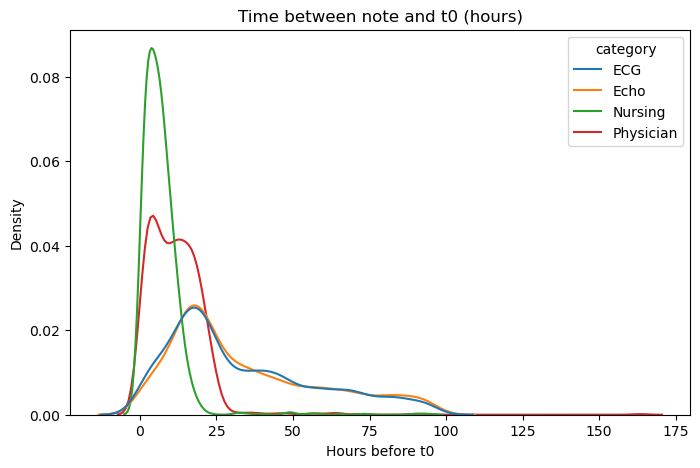

In [80]:
import seaborn as sns
from matplotlib import pyplot as plt
df = closest_notes.copy()
df["delta_hours"] = (df["t0_time"] - df["time"]).dt.total_seconds() / 3600.0


plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="delta_hours", hue="category", common_norm=False)
plt.title("Time between note and t0 (hours)")
plt.xlabel("Hours before t0")
plt.ylabel("Density")
plt.show()

In [82]:
meta_df

{'source_metadata': {'med_metadata_path': '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data_3/med_tensors_output/med_tensors_metadata.pkl',
  'physio_metadata_path': '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/processed_data_3/physio_tensors_output/physio_tensors_metadata.pkl',
  'med_data_path': '/n/netscratch/mzitnik_lab/Lab/rconci/BIOMM/numerics/trig_with_waveform.parquet'},
 'trajectories': {'100098_53': {'hadm_id': np.int64(100098),
   'traj_id': '100098_53',
   'action_cluster_id': 53,
   't0_time': Timestamp('2108-04-11 09:56:00'),
   'trajectory_end_time': Timestamp('2108-04-11 10:02:00'),
   'duration_minutes': 6.0,
   'medications_at_t0': {'NaCl 0.9%': 0.0551551490125,
    'Norepinephrine': 0.2571634169689814},
   'n_medications_at_t0': 2,
   'trigger_medications': ['NaCl 0.9%', 'Norepinephrine'],
   'n_trigger_medications': 2,
   'ic_tensor_path': None,
   'prediction_targets_path': None,
   'has_abp_mean': False,
   'has_cvp': False,
   'abp_mean_value': None,
   '

## SPAGHETTI PLOTS

In [18]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple, Iterable, Sequence

# Helper: earliest trigger time (t0) per (hadm_id, action_cluster_id)
def _t0_from_triggers(trig_df: pd.DataFrame) -> pd.DataFrame:
    m = trig_df.copy()
    m["trigger"] = m["trigger"].fillna(False)
    m["start_time"] = pd.to_datetime(m["start_time"], errors="coerce", utc=True)
    t0 = (m.loc[m["trigger"]]
            .groupby(["hadm_id","action_cluster_id"], as_index=False)["start_time"]
            .min()
            .rename(columns={"start_time":"t0"}))
    return t0.dropna(subset=["t0"])

# Helper: fixed relative grid (in minutes) for ±pre/post at a given sampling freq
def _relative_grid_minutes(pre_min: int, post_min: int, freq: str) -> np.ndarray:
    # freq like "10S" (10 seconds) or "1min"
    if freq.lower().endswith("s"):
        step_sec = int(freq[:-1])
        step_min = step_sec / 60.0
    elif freq.lower().endswith("min"):
        step_min = float(freq[:-3])
    else:
        raise ValueError(f"Unsupported freq '{freq}' (use e.g. '10S' or '1min').")
    # inclusive of both ends
    n_steps = int(round((pre_min + post_min) / step_min))
    # create from -pre to +post with step_min
    rel = np.round(np.arange(-pre_min, post_min + step_min/2, step_min), 6)
    return rel

def build_spaghetti_data_for_combo(
    numerics_df: pd.DataFrame,
    trig_with_waveform: pd.DataFrame,
    cluster_combo_map: pd.DataFrame,
    combo: Tuple[str, ...],
    signals: Sequence[str] = ("ABP_MEAN", "CVP", "HR"),
    pre_minutes: int = 20,
    post_minutes: int = 20,
    freq: str = "10S",                 # match your numerics cadence
    min_non_nan_frac: float = 0.25,    # row kept if ≥ this fraction of samples are non-NaN
) -> Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    """
    Returns {signal: (M, mean_vec, rel_idx_minutes)} where:
      - M is (#clusters x #timepoints) matrix aligned to t0
      - mean_vec is the column-wise nanmean of M
      - rel_idx_minutes is the relative time axis in minutes
    Only clusters whose combo == `combo` are used.
    """
    # 1) figure out which clusters have this combo
    cc = cluster_combo_map.copy()
    if not {"hadm_id","action_cluster_id","combo"}.issubset(cc.columns):
        raise KeyError("cluster_combo_map must have ['hadm_id','action_cluster_id','combo']")
    # ensure tuple type for comparison
    cc["combo"] = cc["combo"].apply(lambda x: tuple(x) if isinstance(x, (list, tuple)) else (x,) if pd.notna(x) else tuple())
    target = cc.loc[cc["combo"] == tuple(combo), ["hadm_id","action_cluster_id"]].drop_duplicates()
    if target.empty:
        # No clusters with this combo; return empty matrices
        rel_idx = _relative_grid_minutes(pre_minutes, post_minutes, freq)
        return {sig: (np.empty((0, len(rel_idx))), np.full(len(rel_idx), np.nan), rel_idx) for sig in signals}

    # 2) earliest trigger t0 per (hadm_id, cluster)
    t0_tbl = _t0_from_triggers(trig_with_waveform)
    t0_tbl = t0_tbl.merge(target, on=["hadm_id","action_cluster_id"], how="inner")
    if t0_tbl.empty:
        rel_idx = _relative_grid_minutes(pre_minutes, post_minutes, freq)
        return {sig: (np.empty((0, len(rel_idx))), np.full(len(rel_idx), np.nan), rel_idx) for sig in signals}

    # 3) prepare numerics
    df = numerics_df.copy()
    df["absolute_timestamp"] = pd.to_datetime(df["absolute_timestamp"], errors="coerce", utc=True)
    # keep only rows for hadm_ids in play, and only needed columns
    keep_cols = ["hadm_id","record_name","absolute_timestamp"] + [s for s in signals if s in df.columns]
    df = df.loc[df["hadm_id"].isin(t0_tbl["hadm_id"].unique()), keep_cols]
    # sort for grouping
    df = df.sort_values(["hadm_id","record_name","absolute_timestamp"])

    # 4) build per-cluster time windows & collect rows into matrices
    rel_idx = _relative_grid_minutes(pre_minutes, post_minutes, freq)
    step_min = np.diff(rel_idx).mean() if len(rel_idx) > 1 else (10/60.0)
    delta_pre  = pd.to_timedelta(pre_minutes, unit="m")
    delta_post = pd.to_timedelta(post_minutes, unit="m")

    # For fast lookups, group numerics by hadm_id
    by_hadm = {k: g for k, g in df.groupby("hadm_id", sort=False, dropna=False)}

    out: Dict[str, list] = {sig: [] for sig in signals if sig in df.columns}

    for _, row in t0_tbl.iterrows():
        hadm = row["hadm_id"]
        t0   = row["t0"]
        # pull hadm numerics
        g = by_hadm.get(hadm)
        if g is None or g.empty:
            continue
        # window slice
        mask = (g["absolute_timestamp"] >= (t0 - delta_pre)) & (g["absolute_timestamp"] <= (t0 + delta_post))
        gw = g.loc[mask].copy()
        if gw.empty:
            continue
        # relative minutes
        rel_min = (gw["absolute_timestamp"] - t0).dt.total_seconds().to_numpy() / 60.0
        # bin/align onto the fixed rel_idx grid by rounding to nearest bin
        # build indexers: round to grid
        # map each rel_min to nearest grid point
        # (vectorized nearest-index)
        idx = np.searchsorted(rel_idx, rel_min)
        # clamp to nearest of neighbors
        idx = np.clip(idx, 0, len(rel_idx)-1)
        # a second pass to choose the closer neighbor when between bins
        # (optional; current approach is acceptable for 10s cadence)
        # aggregate by taking mean per bin per signal
        for sig in out.keys():
            vals = pd.to_numeric(gw[sig], errors="coerce").to_numpy()
            bin_sum = np.zeros(len(rel_idx))
            bin_cnt = np.zeros(len(rel_idx))
            # accumulate
            np.add.at(bin_sum, idx, np.nan_to_num(vals, nan=0.0))
            np.add.at(bin_cnt, idx, ~np.isnan(vals))
            # mean per bin
            with np.errstate(invalid="ignore", divide="ignore"):
                rowv = bin_sum / bin_cnt
            rowv[bin_cnt == 0] = np.nan
            # keep only if enough coverage
            if np.isfinite(rowv).sum() >= min_non_nan_frac * len(rowv):
                out[sig].append(rowv)

    # 5) stack and make means
    data_by_signal: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]] = {}
    for sig in signals:
        if sig not in out:
            continue
        rows = out[sig]
        if not rows:
            M = np.empty((0, len(rel_idx)))
            mean_vec = np.full(len(rel_idx), np.nan)
        else:
            M = np.vstack(rows).astype(float)
            mean_vec = np.nanmean(M, axis=0)
        data_by_signal[sig] = (M, mean_vec, rel_idx)

    return data_by_signal

In [19]:
def _sanitize(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "-_." else "_" for ch in str(s))

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, Tuple

def plot_spaghetti_for_type(
    data_by_signal: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]],
    cluster_type: Tuple[str, ...],
    signals: Tuple[str, ...],
    outdir: str = "outputs_cluster_types",
    faint_alpha: float = 0.25,
    faint_lw: float = 1.0,
    mean_lw: float = 2.7,
):
    """
    Render-only function: given (M, mean, rel_idx) per signal,
    save one PNG per signal for this cluster_type.
    """
    out_path = Path(outdir)
    out_path.mkdir(parents=True, exist_ok=True)

    title_type = " + ".join(cluster_type) if len(cluster_type) else "EMPTY_SET"
    artifacts = []
    for sig in signals:
        M, mean_vec, rel_idx = data_by_signal[sig]
        if M.shape[0] == 0:
            continue
        plt.figure(figsize=(8, 4.5))
        for rowv in M:
            plt.plot(rel_idx, rowv, alpha=faint_alpha, linewidth=faint_lw)
        if np.isfinite(mean_vec).any():
            plt.plot(rel_idx, mean_vec, linewidth=mean_lw, label="mean")
        # vertical line at t=0 (solid, faint)
        plt.axvline(0, color="black", alpha=0.3, linewidth=1.0, linestyle="-")
        plt.title(f"{sig} — {title_type} (n={M.shape[0]} clusters)")
        plt.xlabel("Minutes relative to t0")
        plt.ylabel(sig)
        plt.grid(True, linestyle=":")
        if np.isfinite(mean_vec).any():
            plt.legend(loc="upper right")
        fname = out_path / f"{_sanitize(title_type)}__{_sanitize(sig)}__n{M.shape[0]}.png"
        plt.tight_layout()
        plt.savefig(fname, dpi=160)
        artifacts.append(str(fname))
    return artifacts

In [20]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import re
from typing import Dict, Tuple

def _sanitize(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", s)

def _nearest_idx(rel_idx: np.ndarray, minute_mark: float) -> int:
    return int(np.argmin(np.abs(rel_idx - minute_mark)))

def plot_spaghetti_for_type_colored(
    data_by_signal: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]],
    cluster_type: Tuple[str, ...],
    signals: Tuple[str, ...],
    outdir: str = "outputs_cluster_types",
    faint_lw: float = 0.8,
    mean_lw: float = 2.4,
    baseline_min: float = 0.0,     # compare relative to t0
    end_min: float = 20.0,         # color by change at +20 min
    cmap_name: str = "coolwarm",   # diverging colormap
    robust_lo: float = 5.0,        # use 5th–95th pct for color scaling
    robust_hi: float = 95.0,
    show_colorbar: bool = True,
):
    """
    Colors each spaghetti line by delta = value(end_min) - value(baseline_min).
    Uses robust scaling to map deltas to colors. Also overlays mean (green).
    Saves one PNG per signal.
    """
    out_path = Path(outdir)
    out_path.mkdir(parents=True, exist_ok=True)

    title_type = " + ".join(cluster_type) if len(cluster_type) else "EMPTY_SET"
    artifacts = []

    for sig in signals:
        if sig not in data_by_signal:
            continue
        M, mean_vec, rel_idx = data_by_signal[sig]
        if M.shape[0] == 0:
            continue

        i0  = _nearest_idx(rel_idx, baseline_min)
        i20 = _nearest_idx(rel_idx, end_min)

        # compute per-row delta with nan-safe picks
        base_vals = M[:, i0]
        end_vals  = M[:, i20]
        deltas = end_vals - base_vals

        # robust scaling limits (ignore NaNs)
        finite = np.isfinite(deltas)
        if not finite.any():
            # fallback: plain gray lines
            line_color = (0, 0, 0, 0.15)
            plt.figure(figsize=(8, 4.5))
            for rowv in M:
                plt.plot(rel_idx, rowv, linewidth=faint_lw, color=line_color)
            if np.isfinite(mean_vec).any():
                plt.plot(rel_idx, mean_vec, linewidth=mean_lw, color="green", label="mean")
            plt.axvline(0, color="gray", alpha=0.4, linewidth=1.2, linestyle="-")
            plt.title(f"{sig} — {title_type} (n={M.shape[0]} clusters)")
            plt.xlabel("Minutes relative to t0"); plt.ylabel(sig)
            plt.grid(True, linestyle=":", color="lightgray", alpha=0.7)
            if np.isfinite(mean_vec).any(): plt.legend(loc="upper right")
            fname = out_path / f"{_sanitize(title_type)}__{_sanitize(sig)}__n{M.shape[0]}__plain.png"
            plt.tight_layout(); plt.savefig(fname, dpi=160); plt.close()
            artifacts.append(str(fname))
            continue

        # robust color scaling
        vmin = np.nanpercentile(deltas[finite], robust_lo)
        vmax = np.nanpercentile(deltas[finite], robust_hi)
        max_abs = max(abs(vmin), abs(vmax))
        vmin, vmax = -max_abs, max_abs
        cmap = mpl.cm.get_cmap(cmap_name)
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

        # alpha scaling by |delta|
        min_alpha, max_alpha = 0.1, 0.9
        abs_deltas = np.abs(deltas[finite])
        lo, hi = np.nanpercentile(abs_deltas, 5), np.nanpercentile(abs_deltas, 95)
        if hi == lo: hi = lo + 1e-6
        norm_abs = (np.abs(deltas) - lo) / (hi - lo)
        norm_abs = np.clip(norm_abs, 0, 1)
        alphas = min_alpha + (max_alpha - min_alpha) * norm_abs

        # draw
        order = np.argsort(np.abs(np.where(finite, deltas, 0)))[::-1]
        plt.figure(figsize=(8, 4.5))
        for idx in order:
            rowv = M[idx]
            d = deltas[idx]
            color = cmap(norm(d)) if np.isfinite(d) else (0, 0, 0, 1)
            alpha = alphas[idx] if np.isfinite(d) else min_alpha
            plt.plot(rel_idx, rowv, linewidth=faint_lw, color=color, alpha=alpha)

        # overlay mean in green
        if np.isfinite(mean_vec).any():
            plt.plot(rel_idx, mean_vec, linewidth=mean_lw, color="green", label="mean")

        # vertical t0 line (solid, faint)
        plt.axvline(0, color="gray", alpha=0.4, linewidth=1.2, linestyle="-")

        # cosmetics
        plt.title(f"{sig} — {title_type} (n={M.shape[0]} clusters)")
        plt.xlabel("Minutes relative to t0"); plt.ylabel(sig)
        plt.grid(True, linestyle=":", color="lightgray", alpha=0.7)
        if np.isfinite(mean_vec).any(): plt.legend(loc="upper right")

        # colorbar keyed to delta
        if show_colorbar:
            ax = plt.gca()
            sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=ax, pad=0.02)
            cbar.set_label(f"{sig} Δ @ +{int(end_min)} min vs t0")

        fname = out_path / f"{_sanitize(title_type)}__{_sanitize(sig)}__n{M.shape[0]}__colored.png"
        plt.tight_layout(); plt.savefig(fname, dpi=160); plt.close()
        artifacts.append(str(fname))

    return artifacts

In [21]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import re

import numpy as np
import pandas as pd
from typing import Sequence

def stratified_delta_sample(
    deltas: np.ndarray,
    n_total: int = 400,
    quantile_edges: Sequence[float] = (0.0, 0.1, 0.3, 0.7, 0.9, 1.0),
    random_state: int = 0,
) -> np.ndarray:
    """
    Return indices for a stratified sample across |delta| magnitude and sign.
    We split into negative vs positive, then take quantile bins by |delta|.

    quantile_edges are within [0,1] on |delta| distribution (finite only).
    """
    rng = np.random.default_rng(random_state)
    finite = np.isfinite(deltas)
    idx_all = np.arange(len(deltas))
    chosen = []

    # sign splits
    for sign_mask in [deltas < 0, deltas >= 0]:
        mask = finite & sign_mask
        if not mask.any():
            continue
        abs_d = np.abs(deltas[mask])
        idx_local = idx_all[mask]

        # compute quantile cutpoints
        qs = np.quantile(abs_d, quantile_edges)
        # build bins
        for qlo, qhi in zip(qs[:-1], qs[1:]):
            in_bin = (abs_d >= qlo) & (abs_d <= qhi)
            bin_idx = idx_local[in_bin]
            if len(bin_idx) == 0:
                continue
            # target equal per-bin
            per_bin = max(1, n_total // (2 * (len(qs) - 1)))
            if len(bin_idx) > per_bin:
                pick = rng.choice(bin_idx, size=per_bin, replace=False)
            else:
                pick = bin_idx
            chosen.append(pick)

    if not chosen:
        return np.array([], dtype=int)
    chosen = np.unique(np.concatenate(chosen))
    # cap to n_total overall
    if len(chosen) > n_total:
        chosen = np.random.default_rng(random_state).choice(chosen, size=n_total, replace=False)
    return np.sort(chosen)

def timewise_quantile_band(M: np.ndarray, q_lo: float = 0.10, q_hi: float = 0.90):
    """
    Compute per-timepoint quantiles ignoring NaNs.
    Returns (lo, hi) arrays of shape (T,).
    """
    lo = np.nanquantile(M, q_lo, axis=0)
    hi = np.nanquantile(M, q_hi, axis=0)
    return lo, hi

def _sanitize(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", s)

def plot_spaghetti_for_type_colored_downsampled(
    data_by_signal,
    cluster_type,
    signals=("ABP_MEAN","CVP","HR"),
    outdir="outputs_cluster_types",
    baseline_min=0.0,
    end_min=20.0,
    cmap_name="coolwarm",
    robust_lo=5.0, robust_hi=95.0,
    n_lines: int = 400,              # total lines to plot per figure
    mean_lw: float = 2.4,
    base_lw: float = 0.8,
    min_alpha: float = 0.08,
    max_alpha: float = 0.9,
    band_q: tuple[float,float] = (0.1, 0.9),  # 10–90% band
    random_state: int = 0,
):
    Path(outdir).mkdir(parents=True, exist_ok=True)
    title_type = " + ".join(cluster_type) if len(cluster_type) else "EMPTY_SET"
    artifacts = []

    def nearest_idx(rel_idx, minute_mark: float) -> int:
        return int(np.argmin(np.abs(rel_idx - minute_mark)))

    for sig in signals:
        if sig not in data_by_signal:
            continue
        M, mean_vec, rel_idx = data_by_signal[sig]
        if M.shape[0] == 0:
            continue

        i0  = nearest_idx(rel_idx, baseline_min)
        ixx = nearest_idx(rel_idx, end_min)
        base_vals = M[:, i0]
        end_vals  = M[:, ixx]
        deltas    = end_vals - base_vals
        finite    = np.isfinite(deltas)

        # color scaling (robust)
        vmin = np.nanpercentile(deltas[finite], robust_lo) if finite.any() else -1.0
        vmax = np.nanpercentile(deltas[finite], robust_hi) if finite.any() else  1.0
        max_abs = max(abs(vmin), abs(vmax))
        vmin, vmax = -max_abs, max_abs
        cmap = mpl.cm.get_cmap(cmap_name)
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

        # alpha scaling by |delta| (robust)
        abs_finite = np.abs(deltas[finite]) if finite.any() else np.array([0.0])
        lo, hi = (np.nanpercentile(abs_finite, 5), np.nanpercentile(abs_finite, 95)) if finite.any() else (0.0, 1.0)
        if hi == lo: hi = lo + 1e-6
        norm_abs = (np.abs(deltas) - lo) / (hi - lo)
        norm_abs = np.clip(norm_abs, 0, 1)
        alphas = min_alpha + (max_alpha - min_alpha) * norm_abs

        # ---- stratified sampling of lines to plot
        sample_idx = stratified_delta_sample(deltas, n_total=n_lines, random_state=random_state)
        if sample_idx.size == 0:
            sample_idx = np.arange(min(n_lines, M.shape[0]))

        # ---- figure
        plt.figure(figsize=(8.5, 4.8))

        # percentile band from ALL rows (don’t lose the distribution)
        try:
            qlo, qhi = timewise_quantile_band(M, band_q[0], band_q[1])
            plt.fill_between(rel_idx, qlo, qhi, color="gray", alpha=0.15, linewidth=0, label=f"{int(band_q[0]*100)}–{int(band_q[1]*100)}% band")
        except Exception:
            pass

        # draw downsampled lines
        # (sort so extreme lines don’t get completely covered)
        order = sample_idx[np.argsort(np.abs(deltas[sample_idx]))[::-1]]
        for idx in order:
            color = cmap(norm(deltas[idx])) if np.isfinite(deltas[idx]) else (0,0,0,1)
            plt.plot(rel_idx, M[idx], linewidth=base_lw, color=color, alpha=alphas[idx])

        # mean line
        if np.isfinite(mean_vec).any():
            plt.plot(rel_idx, mean_vec, linewidth=mean_lw, color="black", label="mean")

        # t0 line & cosmetics
        plt.axvline(0, color="gray", alpha=0.4, linewidth=1.2, linestyle="-")
        plt.title(f"{sig} — {title_type} (n={M.shape[0]} clusters, showing {len(order)})")
        plt.xlabel("Minutes relative to t0"); plt.ylabel(sig)
        plt.grid(True, linestyle=":", color="lightgray", alpha=0.7)

        # colorbar
        ax = plt.gca()
        sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.02); cbar.set_label(f"{sig} Δ @ +{int(end_min)} min vs t0")

        plt.legend(loc="upper right")
        fname = Path(outdir) / f"{_sanitize(title_type)}__{_sanitize(sig)}__n{M.shape[0]}__shown{len(order)}.png"
        plt.tight_layout(); plt.savefig(fname, dpi=160); plt.close()
        artifacts.append(str(fname))

    return artifacts

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
from typing import Dict, Tuple, Sequence

def _nearest_idx(rel_idx: np.ndarray, minute_mark: float) -> int:
    return int(np.argmin(np.abs(rel_idx - minute_mark)))

def _fill_small_gaps_1d(x: np.ndarray, max_gap_points: int = 0) -> np.ndarray:
    """
    Optionally fill small NaN runs (<= max_gap_pts) by linear interp.
    If max_gap_pts == 0, returns x unchanged.
    """
    if max_gap_points <= 0 or x.size == 0 or not np.isnan(x).any():
        return x
    s = pd.Series(x, dtype="float64")
    # mark long gaps so they remain NaN
    isnan = s.isna().to_numpy()
    if not isnan.any():
        return x
    # find contiguous NaN runs
    runs = []
    i = 0
    n = len(isnan)
    while i < n:
        if isnan[i]:
            j = i
            while j < n and isnan[j]:
                j += 1
            runs.append((i, j - 1))
            i = j
        else:
            i += 1
    # only interpolate runs <= max_gap_pts
    mask_interp = np.zeros(n, dtype=bool)
    for a, b in runs:
        if (b - a + 1) <= max_gap_points:
            mask_interp[a:b+1] = True
    s2 = s.copy()
    s2[~mask_interp & s.isna()] = np.nan  # keep long gaps as NaN
    s2 = s2.interpolate(limit=max_gap_points, limit_direction="both")
    # don’t fill edges if they were long gaps
    return s2.to_numpy()

def select_showcase_rows(
    data_by_signal: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]],
    primary_signal: str = "ABP_MEAN",
    baseline_ranges: Dict[str, Tuple[float, float]] = None,  # e.g. {"HR":(105,110),"CVP":(5,10),"ABP_MEAN":(50,80)}
    pre_minutes: int = 20,
    post_minutes: int = 20,
    min_coverage: float = 0.98,         # require >= this fraction finite across window (primary)
    max_gap_points: int = 1,            # fill tiny NaN gaps up to this many points in primary
    target_n: int = 20,                  # how many exemplars to return
    random_state: int = 0,
):
    """
    Returns (row_indices, deltas, rel_idx). Indices refer to the row order in data_by_signal[primary_signal][0].
    """
    if primary_signal not in data_by_signal:
        return np.array([], dtype=int), np.array([]), None

    Mp, _, rel = data_by_signal[primary_signal]
    if Mp.size == 0:
        return np.array([], dtype=int), np.array([]), rel

    i0 = _nearest_idx(rel, 0.0)
    i_end = _nearest_idx(rel, post_minutes)

    # 1) Baseline filter across all provided signals
    keep = np.ones(Mp.shape[0], dtype=bool)
    if baseline_ranges:
        for sig, (lo, hi) in baseline_ranges.items():
            if sig in data_by_signal and data_by_signal[sig][0].size:
                Msig = data_by_signal[sig][0]
                # align to primary by truncating to min rows (assumes consistent ordering)
                n = min(Msig.shape[0], keep.shape[0])
                base_vals = Msig[:n, _nearest_idx(data_by_signal[sig][2], 0.0)]
                mask_sig = np.isfinite(base_vals) & (base_vals >= lo) & (base_vals <= hi)
                keep[:n] &= mask_sig
            # if sig not present, ignore that constraint

    # 2) Coverage filter on primary + optional tiny-gap filling (non-destructive for selection)
    kept_rows = []
    deltas = []
    rng = np.random.default_rng(random_state)
    for r in np.where(keep)[0]:
        row = Mp[r].astype(float, copy=True)
        # small gap fill for coverage test
        row_filled = _fill_small_gaps_1d(row, max_gap_points=max_gap_points)
        cov = np.isfinite(row_filled).mean()
        if cov < min_coverage:
            continue
        if not np.isfinite(row_filled[i0]) or not np.isfinite(row_filled[i_end]):
            continue
        kept_rows.append(r)
        deltas.append(row_filled[i_end] - row_filled[i0])

    if not kept_rows:
        return np.array([], dtype=int), np.array([]), rel

    kept_rows = np.array(kept_rows, dtype=int)
    deltas = np.array(deltas, dtype=float)

    # 3) Span spectrum: take extremes + quantile representatives around 0
    #    Build symmetric quantile grid and pick nearest rows to those quantiles.
    quantiles = np.array([0.0, 0.05, 0.15, 0.3, 0.5, 0.7, 0.85, 0.95, 1.0])
    q_vals = np.nanquantile(deltas, quantiles)
    chosen = set()

    # Always include min, median, max first
    targets = [q_vals[0], q_vals[4], q_vals[-1]]

    # Then fill from remaining quantiles until target_n
    for qv in q_vals:
        if len(targets) >= target_n:
            break
        targets.append(qv)

    # For each target delta, pick the closest row not yet chosen
    for tv in targets:
        idx_pool = np.setdiff1d(np.arange(len(kept_rows)), list(chosen), assume_unique=False)
        if idx_pool.size == 0: break
        pick_local = idx_pool[np.argmin(np.abs(deltas[idx_pool] - tv))]
        chosen.add(int(pick_local))

    chosen = list(chosen)

    # If still short, sprinkle randomly among remaining (but bias to tails)
    if len(chosen) < target_n:
        left = np.setdiff1d(np.arange(len(kept_rows)), chosen, assume_unique=False)
        if left.size:
            # importance weights ~ |delta| (more likely extremes)
            w = np.abs(deltas[left]).astype(float)
            if np.all(w == 0) or not np.isfinite(w).any():
                extra = rng.choice(left, size=min(target_n - len(chosen), left.size), replace=False)
            else:
                w = w / w.sum()
                extra = rng.choice(left, size=min(target_n - len(chosen), left.size), replace=False, p=w)
            chosen.extend(list(extra))

    chosen = np.array(chosen[:target_n], dtype=int)
    return kept_rows[chosen], deltas[chosen], rel


import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from typing import Dict, Tuple, Sequence

def plot_showcase_panel(
    data_by_signal, row_indices, rel_idx, combo_title,
    signals=("ABP_MEAN","CVP","HR"),
    post_minutes=20, outdir="outputs_showcase",
    cmap_name="coolwarm",
    fill_small_gaps_plot: int = 2,   # <= fill gaps up to N points for plotting
):
    Path(outdir).mkdir(parents=True, exist_ok=True)
    artifacts = []

    for sig in signals:
        if sig not in data_by_signal: 
            continue
        M, _, rel = data_by_signal[sig]
        if M.size == 0: 
            continue

        idx_sig = row_indices[row_indices < M.shape[0]]
        if idx_sig.size == 0:
            continue

        Ms = M[idx_sig].astype(float)
        i0   = int(np.argmin(np.abs(rel - 0.0)))
        iend = int(np.argmin(np.abs(rel - float(post_minutes))))
        base = Ms[:, i0]; end = Ms[:, iend]
        deltas = end - base
        finite = np.isfinite(deltas)

        fig, ax = plt.subplots(figsize=(8.2, 4.6))

        if finite.any():
            vmin = np.nanpercentile(deltas[finite], 5)
            vmax = np.nanpercentile(deltas[finite], 95)
            max_abs = max(abs(vmin), abs(vmax))
            norm = mpl.colors.Normalize(vmin=-max_abs, vmax=max_abs)
            cmap = mpl.cm.get_cmap(cmap_name)

            abs_d = np.abs(deltas[finite])
            lo, hi = np.nanpercentile(abs_d, [5, 95])
            if not np.isfinite(hi) or hi <= lo: hi = lo + 1e-6
            abs_all = np.abs(deltas)
            alpha = 0.25 + 0.65 * np.clip((abs_all - lo)/(hi - lo), 0, 1)

            order = np.argsort(np.abs(deltas))[::-1]
            Y_for_mean = []
            for k in order:
                y = Ms[k]
                if fill_small_gaps_plot > 0:
                    y = _fill_small_gaps_1d(y, max_gap_points=fill_small_gaps_plot)
                Y_for_mean.append(y)
                c = cmap(norm(deltas[k])) if np.isfinite(deltas[k]) else (0,0,0,1)
                a = float(alpha[k]) if np.isfinite(alpha[k]) else 0.25
                ax.plot(
                    rel, y, color=c, alpha=a, linewidth=2.0,
                    linestyle="-", solid_capstyle="round", solid_joinstyle="round"
                )
            Y_for_mean = np.vstack(Y_for_mean)
            mean_vec = np.nanmean(Y_for_mean, axis=0)
            ax.plot(
                rel, mean_vec, color="black", linewidth=2.5, label="mean of selected",
                linestyle="-", solid_capstyle="round", solid_joinstyle="round"
            )

            sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
            cbar = fig.colorbar(sm, ax=ax, pad=0.02)
            cbar.set_label(f"{sig} Δ @ +{post_minutes} min vs t0")
        else:
            # fallback gray lines, solid
            for y in Ms:
                if fill_small_gaps_plot > 0:
                    y = _fill_small_gaps_1d(y, max_gap_points=fill_small_gaps_plot)
                ax.plot(rel, y, color="gray", alpha=0.3, linewidth=2.0,
                        linestyle="-", solid_capstyle="round", solid_joinstyle="round")

            mean_vec = np.nanmean(Ms, axis=0)
            ax.plot(rel, mean_vec, color="black", linewidth=2.5, label="mean of selected",
                    linestyle="-", solid_capstyle="round", solid_joinstyle="round")

        # cosmetics
        ax.set_axisbelow(True)  # put grid behind lines
        ax.grid(True, linestyle=":", color="lightgray", alpha=0.7)
        ax.set_title(f"{sig} — {combo_title} (n={len(idx_sig)})")
        ax.set_xlabel("Minutes relative to t0"); ax.set_ylabel(sig)

        # draw t0 line LAST, solid, on top
        ax.axvline(0, color="gray", linewidth=1.8,
           linestyle="-", zorder=10_000)

        ax.legend(loc="upper right")
        fname = Path(outdir) / f"{combo_title.replace(' ','_')}__{sig}__showcase.png"
        fig.tight_layout(); fig.savefig(fname, dpi=170); plt.close(fig)
        artifacts.append(str(fname))

    return artifacts

In [23]:
import re
from pathlib import Path
import matplotlib.pyplot as plt


def plot_spaghetti_for_top_combos(
    numerics_df: pd.DataFrame,
    trig_with_waveform: pd.DataFrame,
    combo_df: pd.DataFrame,
    cluster_combo_map: pd.DataFrame,
    top_k: int = 5,
    signals: Sequence[str] = ("ABP_MEAN","CVP","HR"),
    pre_minutes: int = 20,
    post_minutes: int = 20,
    freq: str = "10S",
    outdir: str = "outputs_cluster_types",
):
    Path(outdir).mkdir(parents=True, exist_ok=True)
    # sort by count descending
    top = combo_df.sort_values("count", ascending=False).head(top_k)

    all_artifacts = []
    for _, row in top.iterrows():
        combo = tuple(row["combo"])
        data_by_signal = build_spaghetti_data_for_combo(
            numerics_df=numerics_df,
            trig_with_waveform=trig_with_waveform,
            cluster_combo_map=cluster_combo_map,
            combo=combo,
            signals=signals,
            pre_minutes=pre_minutes,
            post_minutes=post_minutes,
            freq=freq,
        )
        # use your provided renderer
        arts = plot_spaghetti_for_type_colored_downsampled(
            data_by_signal=data_by_signal,
            cluster_type=combo,
            signals=("ABP_MEAN","CVP","HR"),
            outdir="outputs_cluster_types",
            baseline_min=0.0,
            end_min=20.0,
            n_lines=400,               # plot at most 400 trajectories
            band_q=(0.1, 0.9),         # 10–90% ribbon from ALL rows
        )
        all_artifacts.extend(arts)
    return all_artifacts

In [24]:
from pathlib import Path
from typing import Sequence, List, Tuple, Dict
import numpy as np
import pandas as pd

def plot_spaghetti_for_top_combos_within_baseline_ranges_showcase(
    numerics_df: pd.DataFrame,
    trig_with_waveform: pd.DataFrame,
    combo_df: pd.DataFrame,
    cluster_combo_map: pd.DataFrame,
    top_k: int = 5,
    signals: Sequence[str] = ("ABP_MEAN","CVP","HR"),
    pre_minutes: int = 20,
    post_minutes: int = 20,
    freq: str = "10S",
    outdir: str = "outputs_showcase",
    primary_signal: str = "ABP_MEAN",
    baseline_ranges: Dict[str, Tuple[float, float]] = None,  # e.g. {"HR":(105,110), "CVP":(5,10), "ABP_MEAN":(50,80)}
    target_n: int = 20,
    min_coverage: float = 0.98,
    max_gap_points: int = 1,
) -> List[str]:
    """
    For each of the top-K combos, pick ~target_n continuous trajectories that:
      - fall within baseline_ranges at t0
      - span the response spectrum (super up -> flat -> super down)
    Then render clean showcase panels via plot_showcase_panel.
    """
    Path(outdir).mkdir(parents=True, exist_ok=True)

    if baseline_ranges is None:
        baseline_ranges = {"HR": (105, 110), "CVP": (5, 10), "ABP_MEAN": (50, 80)}

    # Top combos by count
    top = combo_df.sort_values("count", ascending=False).head(top_k)

    all_artifacts: List[str] = []
    for _, row in top.iterrows():
        combo = tuple(row["combo"])

        # Build aligned matrices for this combo
        data_by_signal = build_spaghetti_data_for_combo(
            numerics_df=numerics_df,                 # <- use function arg
            trig_with_waveform=trig_with_waveform,
            cluster_combo_map=cluster_combo_map,
            combo=combo,
            signals=signals,
            pre_minutes=pre_minutes,
            post_minutes=post_minutes,
            freq=freq,
        )

        # Select ~target_n showcase rows
        row_idx, deltas_primary, rel_idx = select_showcase_rows(
            data_by_signal=data_by_signal,
            primary_signal=primary_signal,
            baseline_ranges=baseline_ranges,
            pre_minutes=pre_minutes,
            post_minutes=post_minutes,
            min_coverage=min_coverage,
            max_gap_points=max_gap_points,
            target_n=target_n,
        )

        if row_idx.size == 0:
            # Nothing matched constraints for this combo; skip gracefully
            print(f"[showcase] Skipping combo {combo}: no rows passed filters.")
            continue

        combo_title = " + ".join(combo) if combo else "EMPTY_SET"

        # Render the same selected rows for all signals
        files = plot_showcase_panel(
            data_by_signal=data_by_signal,
            row_indices=row_idx,
            rel_idx=rel_idx,               # passed through (panel recomputes per-signal deltas)
            combo_title=combo_title,
            signals=signals,
            post_minutes=post_minutes,
            outdir=outdir,
        )
        all_artifacts.extend(files)
        print(f"[showcase] {combo_title}: saved {len(files)} figure(s).")

    return all_artifacts

In [29]:
trig_with_waveform.head()

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,patientweight,...,rate/weight_capped,rate/weight_norm,item_label,rate_norm,prev_rate,trigger,trigger_reason,action_cluster_id,action_cluster_size,action_cluster_rank
0,65411,100098,225158,01-Drips,Continuous Med,2108-04-11 09:56:00+00:00,2108-04-11 11:01:00+00:00,6.602113,mL/hour,64.0,...,0.103158,0.055155,NaCl 0.9%,0.055155,0.099358,False,,53,2,<NA>
1,65411,100098,221906,01-Drips,Continuous Med,2108-04-11 09:56:00+00:00,2108-04-11 11:01:00+00:00,0.110035,mcg/kg/min,64.0,...,0.110035,0.257163,Norepinephrine,0.257163,0.231630,False,,53,2,<NA>
2,65411,100098,225158,02-Fluids (Crystalloids),Continuous IV,2108-04-11 10:02:00+00:00,2108-04-12 21:44:00+00:00,5.000000,mL/hour,64.0,...,0.078125,0.041771,NaCl 0.9%,0.041771,0.055155,False,,59,1,<NA>
3,65411,100098,225158,01-Drips,Continuous Med,2108-04-11 11:01:00+00:00,2108-04-11 14:21:00+00:00,8.403035,mL/hour,64.0,...,0.131297,0.070200,NaCl 0.9%,0.070200,0.041771,True,uptitrate_gt25pct_abs>=0.02,53,2,1
4,65411,100098,221906,01-Drips,Continuous Med,2108-04-11 11:01:00+00:00,2108-04-11 14:21:00+00:00,0.140051,mcg/kg/min,64.0,...,0.140051,0.327312,Norepinephrine,0.327312,0.257163,True,uptitrate_gt25pct_abs>=0.02,53,2,2


In [30]:
combo_df_wave, cluster_combo_map_wave = rank_action_window_combinations(trig_with_waveform, window_minutes=20)


In [33]:
cluster_combo_map_wave

,hadm_id,action_cluster_id,combo
0,100098,53,"(NaCl 0.9%, Norepinephrine)"
1,100098,55,"(Albumin 25%, NaCl 0.9%, Norepinephrine)"
2,100098,56,"(NaCl 0.9%, NaCl 0.9% [Bolus], Norepinephrine)"
3,100098,58,"(NaCl 0.9%, Norepinephrine)"
4,100098,59,"(Albumin 25%, NaCl 0.9%)"
...,...,...,...
8744,199751,10,"(Epinephrine,)"
8745,199751,11,"(NaCl 0.9%, Phenylephrine)"
8746,199751,12,"(Albumin 5%, NaCl 0.9%)"
8747,199751,13,"(Epinephrine,)"


In [26]:
wf_10s_smoothed_despiked.head()

,absolute_timestamp,ABP_MEAN,CVP,HR,RESP,SpO2,CO,PULSE,hadm_id,record_name,record_start_time,record_end_time,ABP_MEAN_smooth4,CVP_smooth4,HR_smooth4,RESP_smooth4,SpO2_smooth4,CO_smooth4,PULSE_smooth4
0,2108-04-11 07:50:00+00:00,69.499279,9.616217,102.099798,15.049975,NaN,NaN,101.466897,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,71.671752,9.577487,102.294187,15.349984,NaN,NaN,101.544366
1,2108-04-11 07:50:10+00:00,70.585515,9.596852,102.196992,15.199979,NaN,NaN,101.505631,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,72.214870,9.567804,102.342784,15.424986,NaN,NaN,101.563733
2,2108-04-11 07:50:20+00:00,71.671752,9.577487,102.294187,15.349984,NaN,NaN,101.544366,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,72.757988,9.558122,102.391381,15.499988,NaN,NaN,101.583101
3,2108-04-11 07:50:30+00:00,72.757988,9.558122,102.391381,15.499988,NaN,NaN,101.583101,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,73.261861,9.559505,102.440331,15.513878,NaN,NaN,101.621931
4,2108-04-11 07:50:40+00:00,73.844224,9.538757,102.488576,15.649993,NaN,NaN,101.621836,100098,p065411-2108-04-11-07-50n,2108-04-11 07:50:08+00:00,2108-04-17 19:03:07.999999+00:00,73.739570,9.568265,102.489515,15.487026,NaN,NaN,101.673735


In [35]:
arts = plot_spaghetti_for_top_combos_within_baseline_ranges_showcase(
    numerics_df=wf_10s_smoothed_despiked,
    trig_with_waveform=trig_with_waveform,
    combo_df=combo_df_wave,
    cluster_combo_map=cluster_combo_map_wave,
    top_k=10,
    signals=("ABP_MEAN_smooth4","CVP_smooth4","HR_smooth4"),
    pre_minutes=20,
    post_minutes=20,
    freq="10S",
    outdir="outputs_showcase",
    baseline_ranges={
        "HR_smooth4": (100,120),
        "CVP_smooth4": (0,10),
        "ABP_MEAN_smooth4": (50,80),
    },
    primary_signal="ABP_MEAN_smooth4",  # <- IMPORTANT
    target_n=30,
    min_coverage=0.90,                  # <- a bit looser
    max_gap_points=2,                   # <- fill tiny holes
)

/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/2145155476.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/2145155476.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/2145155476.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplot

[showcase] NaCl 0.9% + Phenylephrine: saved 3 figure(s).


/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/2145155476.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/2145155476.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/2145155476.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplot

[showcase] NaCl 0.9% + Norepinephrine: saved 3 figure(s).


/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/2145155476.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/2145155476.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/2145155476.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplot

...

/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/2145155476.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/2145155476.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)


[showcase] NaCl 0.9% + Vasopressin: saved 2 figure(s).


/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/2145155476.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/2145155476.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)


[showcase] NaCl 0.9% + Norepinephrine + Phenylephrine: saved 3 figure(s).


/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_97947/2145155476.py:188: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)


In [102]:
import numpy as np

def _nearest_idx(rel_idx: np.ndarray, minute_mark: float) -> int:
    return int(np.argmin(np.abs(rel_idx - minute_mark)))

def deltas_from_data_by_signal(
    data_by_signal: dict,
    signal: str,
    baseline_min: float = 0.0,
    end_min: float = 20.0,
) -> np.ndarray:
    """
    Extract Δ = value(end_min) - value(baseline_min) for all rows in M for `signal`.
    Returns a 1D array of deltas (NaNs removed).
    """
    if signal not in data_by_signal:
        return np.array([], dtype=float)
    M, _, rel_idx = data_by_signal[signal]
    if M.size == 0:
        return np.array([], dtype=float)

    i0  = _nearest_idx(rel_idx, baseline_min)
    ixx = _nearest_idx(rel_idx, end_min)
    base = M[:, i0]
    end  = M[:, ixx]
    deltas = end - base
    return deltas[np.isfinite(deltas)]


import matplotlib.pyplot as plt
from pathlib import Path
import re

def _sanitize(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", s)

def _fd_bins(x: np.ndarray, max_bins: int = 80) -> int:
    """Freedman–Diaconis bin count (fallback to 30)."""
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 5:
        return max(5, min(n, 30))
    q25, q75 = np.percentile(x, [25, 75])
    iqr = q75 - q25
    if iqr <= 0:
        return min(max_bins, max(10, int(np.sqrt(n))))
    binw = 2 * iqr * n ** (-1/3)
    if binw <= 0:
        return 30
    bins = int(np.clip((x.max() - x.min()) / binw, 10, max_bins))
    return max(10, bins)

def plot_delta_histogram(
    deltas: np.ndarray,
    combo: tuple,
    signal: str,
    outdir: str = "outputs_combo_hist",
    end_min_label: int = 20,
    facecolor: str = "#4F7DBD",
    edgecolor: str = "#203A69",
):
    """
    Professional-looking histogram of Δ for one combo+signal, with CDF overlay and stats.
    """
    Path(outdir).mkdir(parents=True, exist_ok=True)
    if deltas.size == 0:
        return None

    # Robust xlim
    lo = np.nanpercentile(deltas, 1)
    hi = np.nanpercentile(deltas, 99)
    pad = 0.05 * (hi - lo if hi > lo else max(1.0, abs(hi)))
    xmin, xmax = lo - pad, hi + pad

    # Bins
    bins = _fd_bins(deltas)

    # Stats
    n = deltas.size
    mean = np.nanmean(deltas)
    med  = np.nanmedian(deltas)
    p5, p95 = np.nanpercentile(deltas, [5, 95])
    q25, q75 = np.nanpercentile(deltas, [25, 75])

    title_type = " + ".join(combo) if combo else "EMPTY_SET"

    fig, ax = plt.subplots(figsize=(7.5, 4.6))

    # Histogram
    ax.hist(
        deltas, bins=bins, density=True,
        color=facecolor, edgecolor=edgecolor, alpha=0.85, linewidth=0.8
    )

    # Vertical reference lines
    ax.axvline(0,    color="gray",  alpha=0.6, linewidth=1.2, linestyle="-", label="Δ=0")
    ax.axvline(med,  color="#2A9D8F", linewidth=1.8, linestyle="-", label=f"median={med:.3g}")
    ax.axvline(mean, color="#E76F51", linewidth=1.8, linestyle="-.", label=f"mean={mean:.3g}")

    # CDF overlay on twin axis
    ax2 = ax.twinx()
    xs = np.sort(deltas[np.isfinite(deltas)])
    ys = np.linspace(0, 1, len(xs), endpoint=True)
    ax2.plot(xs, ys, color="black", alpha=0.35, linewidth=1.4, label="CDF")
    ax2.set_ylim(0, 1)
    ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax2.grid(False)

    # Cosmetics
    ax.set_xlim(xmin, xmax)
    ax.set_title(f"{signal} Δ at +{end_min_label} min — {title_type} (n={n})")
    ax.set_xlabel(f"{signal} Δ (value @ +{end_min_label} min − value @ t0)")
    ax.set_ylabel("Density")
    ax.grid(True, linestyle=":", color="lightgray", alpha=0.7)

    # Stats box
    txt = (
        f"n={n}\n"
        f"mean={mean:.3g}\n"
        f"median={med:.3g}\n"
        f"IQR=({q25:.3g}, {q75:.3g})\n"
        f"5–95%: ({p5:.3g}, {p95:.3g})"
    )
    ax.text(
        0.98, 0.98, txt, transform=ax.transAxes,
        ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="lightgray", alpha=0.9),
        fontsize=9
    )

    # Legend: combine both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    if lines1 or lines2:
        ax.legend(lines1 + lines2, labels1 + labels2, loc="lower right", frameon=True)

    fname = Path(outdir) / f"{_sanitize(title_type)}__{_sanitize(signal)}__delta_hist.png"
    plt.tight_layout()
    plt.savefig(fname, dpi=160)
    plt.close(fig)
    return str(fname)


def plot_delta_histograms_for_top_combos(
    numerics_df: pd.DataFrame,
    trig_with_waveform: pd.DataFrame,
    combo_df: pd.DataFrame,
    cluster_combo_map: pd.DataFrame,
    signals=("ABP_MEAN","CVP","HR"),
    top_k: int = 5,
    pre_minutes: int = 20,
    post_minutes: int = 20,
    freq: str = "10S",
    outdir: str = "outputs_combo_hist",
) -> list[str]:
    """
    For each of the top-K combos, compute deltas per signal and plot histograms.
    Uses your existing `build_spaghetti_data_for_combo` to align windows.
    """
    # Sort by count descending, pick top-K
    top = combo_df.sort_values("count", ascending=False).head(top_k)
    artifacts = []

    for _, row in top.iterrows():
        combo = tuple(row["combo"])
        # build aligned matrices (re-use your function)
        data_by_signal = build_spaghetti_data_for_combo(
            numerics_df=numerics_df,
            trig_with_waveform=trig_with_waveform,
            cluster_combo_map=cluster_combo_map,
            combo=combo,
            signals=signals,
            pre_minutes=pre_minutes,
            post_minutes=post_minutes,
            freq=freq,
        )
        # per signal: compute deltas and plot
        for sig in signals:
            deltas = deltas_from_data_by_signal(
                data_by_signal, signal=sig, baseline_min=0.0, end_min=post_minutes
            )
            if deltas.size == 0:
                continue
            fn = plot_delta_histogram(
                deltas, combo=combo, signal=sig,
                outdir=outdir, end_min_label=post_minutes
            )
            if fn:
                artifacts.append(fn)
    return artifacts

In [143]:
hist_files = plot_delta_histograms_for_top_combos(
    numerics_df=wf_10s_despiked,             # or wf_10s[_smoothed]
    trig_with_waveform=trig_with_waveform,
    combo_df=combo_df_wave,
    cluster_combo_map=cluster_combo_map_wave,
    signals=("ABP_MEAN","CVP","HR"),
    top_k=10,
    pre_minutes=20,
    post_minutes=20,        # Δ computed at +20 min
    freq="10S",
    outdir="outputs_combo_hist",
)

print("Saved histograms:", hist_files[:3], "…")

/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/41490

Saved histograms: ['outputs_combo_hist/NaCl_0.9_Phenylephrine__ABP_MEAN__delta_hist.png', 'outputs_combo_hist/NaCl_0.9_Phenylephrine__CVP__delta_hist.png', 'outputs_combo_hist/NaCl_0.9_Phenylephrine__HR__delta_hist.png'] …


In [148]:
import numpy as np
import pandas as pd
from typing import List, Tuple, Dict, Sequence

def _nearest_idx(rel_idx: np.ndarray, minute_mark: float) -> int:
    return int(np.argmin(np.abs(rel_idx - minute_mark)))

def _combo_to_title(combo: Tuple[str, ...], max_len: int = 60) -> str:
    s = " + ".join(combo) if combo else "EMPTY_SET"
    return s if len(s) <= max_len else s[:max_len-1] + "…"

def collect_combo_deltas(
    numerics_df: pd.DataFrame,
    trig_with_waveform: pd.DataFrame,
    combo_df: pd.DataFrame,
    cluster_combo_map: pd.DataFrame,
    signal: str = "ABP_MEAN",
    top_k: int = 10,
    pre_minutes: int = 20,
    post_minutes: int = 20,
    freq: str = "10S",
) -> pd.DataFrame:
    """
    Returns a tall dataframe with one row per occurrence (combo instance) holding the delta
    for a given `signal` at +post_minutes vs t0 (0.0). Only top_k combos by count are used.
    """
    top = combo_df.sort_values("count", ascending=False).head(top_k)
    rows = []
    for _, r in top.iterrows():
        combo = tuple(r["combo"])
        data = build_spaghetti_data_for_combo(
            numerics_df=numerics_df,
            trig_with_waveform=trig_with_waveform,
            cluster_combo_map=cluster_combo_map,
            combo=combo,
            signals=(signal,),
            pre_minutes=pre_minutes,
            post_minutes=post_minutes,
            freq=freq,
        )
        if signal not in data: 
            continue
        M, _, rel = data[signal]
        if M.size == 0:
            continue
        i0 = _nearest_idx(rel, 0.0)
        i1 = _nearest_idx(rel, float(post_minutes))
        base = M[:, i0]
        end  = M[:, i1]
        d = (end - base).astype(float)
        d = d[np.isfinite(d)]
        if d.size == 0: 
            continue
        for val in d:
            rows.append({"combo": combo, "combo_title": _combo_to_title(combo), "delta": float(val)})
    if not rows:
        return pd.DataFrame(columns=["combo","combo_title","delta"])
    return pd.DataFrame(rows)

def summarize_deltas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregates rows from collect_combo_deltas into per-combo stats.
    """
    if df.empty:
        return pd.DataFrame(columns=["combo_title","n","mean","median","std","p25","p75","ci_lo","ci_hi"])
    g = df.groupby(["combo","combo_title"], as_index=False)["delta"]
    agg = g.agg(
        n=("delta","size"),
        mean=("delta","mean"),
        median=("delta","median"),
        std=("delta","std"),
        p25=("delta", lambda x: np.percentile(x,25)),
        p75=("delta", lambda x: np.percentile(x,75)),
    )
    # 95% CI for the mean (normal approx). If you prefer ±1 SD, we’ll use that in the plot anyway.
    z = 1.96
    agg["ci_lo"] = agg["mean"] - z * (agg["std"] / np.sqrt(np.maximum(1, agg["n"])))
    agg["ci_hi"] = agg["mean"] + z * (agg["std"] / np.sqrt(np.maximum(1, agg["n"])))
    # rank by n desc
    agg = agg.sort_values("mean", ascending=False).reset_index(drop=True)
    return agg

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_forest_seaborn(
    numerics_df: pd.DataFrame,
    trig_with_waveform: pd.DataFrame,
    combo_df: pd.DataFrame,
    cluster_combo_map: pd.DataFrame,
    signal: str = "ABP_MEAN",
    top_k: int = 10,
    pre_minutes: int = 20,
    post_minutes: int = 20,
    freq: str = "10S",
    outdir: str = "outputs_forest",
    error_type: str = "sd",  # {"sd", "ci"}
):
    """
    Make a 'forest plot' of delta @ +post vs t0 for top combos with seaborn.
    """
    Path(outdir).mkdir(parents=True, exist_ok=True)

    # Collect tall df
    tall = collect_combo_deltas(
        numerics_df, trig_with_waveform, combo_df, cluster_combo_map,
        signal=signal, top_k=top_k,
        pre_minutes=pre_minutes, post_minutes=post_minutes, freq=freq
    )
    if tall.empty:
        print(f"[seaborn forest] no deltas for {signal}")
        return ""

    # Summaries
    summ = summarize_deltas(tall).head(top_k)
    if summ.empty:
        return ""

    # Order by count (n)
    summ = summ.sort_values("n", ascending=False)
    order = summ["combo_title"].tolist()

    # Create seaborn plot
    plt.figure(figsize=(9, 6))
    sns.set_style("whitegrid")

    # error bars
    if error_type == "sd":
        err_lo = summ["std"].to_numpy()
        err_hi = summ["std"].to_numpy()
    else:
        err_lo = summ["mean"] - summ["ci_lo"]
        err_hi = summ["ci_hi"] - summ["mean"]
    err = [err_lo, err_hi]

    # scatter points (mean, bubble size)
    sizes = 100 + (summ["n"] / summ["n"].max()) * 500
    sc = plt.scatter(
        x=summ["mean"], y=summ["combo_title"],
        s=sizes, c=summ["mean"], cmap="coolwarm",
        edgecolors="k", alpha=0.9, zorder=3
    )

    # horizontal error bars
    for xi, yi, el, eh in zip(summ["mean"], summ["combo_title"], err_lo, err_hi):
        plt.errorbar(
            xi, yi, xerr=[[el], [eh]],
            fmt="none", ecolor="black", elinewidth=1.4, capsize=4
        )

    # median markers
    plt.scatter(
        x=summ["median"], y=summ["combo_title"],
        marker="D", s=40, color="black", alpha=0.9, label="median"
    )

    # vertical reference at 0
    plt.axvline(0, color="gray", linestyle="--", alpha=0.6)

    # cosmetics
    plt.title(f"{signal} Δ @ +{post_minutes} min vs t0 (Top {top_k} combos)")
    plt.xlabel("Δ (end − baseline)")
    plt.ylabel("Combination")
    plt.grid(True, axis="x", linestyle=":", color="lightgray", alpha=0.7)

    cbar = plt.colorbar(sc)
    cbar.set_label("mean Δ")

    plt.legend(loc="lower right")
    fname = Path(outdir) / f"forest_seaborn_{signal}_top{top_k}.png"
    plt.tight_layout()
    plt.savefig(fname, dpi=170)
    plt.close()
    return str(fname)

In [152]:
out_abp = plot_forest_seaborn(
    numerics_df=wf_10s_despiked,
    trig_with_waveform=trig_with_waveform,
    combo_df=combo_df_wave,
    cluster_combo_map=cluster_combo_map_wave,
    signal="ABP_MEAN",
    top_k=10,
    pre_minutes=20,
    post_minutes=20,
    freq="10S",
    outdir="outputs_forest",
    error_type="ci",   # or "ci"
)
print("Saved:", out_abp)

/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/41490

KeyboardInterrupt: 

In [150]:
# For each signal you care about
out_abp = plot_forest_for_top_combos(
    numerics_df=wf_10s_despiked,      # cleaned 10s numerics
    trig_with_waveform=trig_with_waveform,
    combo_df=combo_df_wave,
    cluster_combo_map=cluster_combo_map_wave,
    signal="ABP_MEAN",
    top_k=10,
    pre_minutes=20,
    post_minutes=20,
    freq="10S",
    outdir="outputs_forest",
    use_sd_bars=False,                 # or False to show 95% CI
)


/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/4149000958.py:139: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_85539/41490

TypeError: func is expected but received tuple in **kwargs.

In [ ]:

out_cvp = plot_forest_for_top_combos(
    numerics_df=wf_10s_despiked,
    trig_with_waveform=trig_with_waveform,
    combo_df=combo_df_wave,
    cluster_combo_map=cluster_combo_map_wave,
    signal="CVP",
    top_k=10,
    pre_minutes=20,
    post_minutes=20,
    freq="10S",
    outdir="outputs_forest",
)
print("Saved:", out_abp, "|", out_cvp)